# PART A — Global configuration

First, replace the scattered configuration in the original notebook with one controlled configuration block.

In [1]:
# ============================================================
# HDBSCAN PARAMETER GRID SEARCH
# Reviewer-Corrected Multi-Omics Pipeline
#
# Modality: miRNA
#
# Pipeline:
# CSV
#   ↓
# Feature extraction
#   ↓
# StandardScaler
#   ↓
# PCA (95% variance)
#   ↓
# HDBSCAN grid search
#   ↓
# Clustering-quality evaluation
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import hdbscan

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

warnings.filterwarnings("ignore")


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)


# ============================================================
# 2. DATASET
# ============================================================

DATA_PATH = "/content/miRNA.csv"

MODALITY = "miRNA"


# ============================================================
# 3. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = (
    f"/content/{MODALITY}_Reviewer_Corrected_Results"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 4. HDBSCAN SEARCH SPACE
# ============================================================

MIN_CLUSTER_SIZES = [
    5,
    10,
    20,
    30,
    40,
    50,
    60,
    70,
    80,
    90,
    100
]

MIN_SAMPLES = [
    1,
    2,
    5,
    10,
    15,
    20,
    25,
    30,
    35,
    40,
    45
]

HDBSCAN_METRIC = "euclidean"

HDBSCAN_CLUSTER_SELECTION = "eom"


# ============================================================
# 5. PCA CONFIGURATION
# ============================================================

PCA_VARIANCE = 0.95


# ============================================================
# 6. LOAD DATASET
# ============================================================

print("=" * 80)
print("LOADING DATASET")
print("=" * 80)

print(
    "Dataset:",
    DATA_PATH
)

df = pd.read_csv(
    DATA_PATH
)

print(
    "Original shape:",
    df.shape
)

print(
    "\nColumns:"
)

print(
    df.columns.tolist()
)


# ============================================================
# 7. IDENTIFY NUMERIC FEATURES
# ============================================================

numeric_columns = df.select_dtypes(
    include=[np.number]
).columns.tolist()


print()
print("=" * 80)
print("NUMERIC FEATURES")
print("=" * 80)

print(
    "Number of numeric columns:",
    len(numeric_columns)
)


# ============================================================
# 8. REMOVE POSSIBLE LABEL / TARGET COLUMNS
# ============================================================
#
# HDBSCAN is unsupervised.
#
# Therefore, outcome / class / label columns must NOT be
# included in the clustering feature matrix.
#
# The code removes common label names if present.
# ============================================================

POSSIBLE_LABEL_COLUMNS = [
    "label",
    "Label",
    "LABEL",
    "class",
    "Class",
    "CLASS",
    "target",
    "Target",
    "TARGET",
    "y",
    "Y",
    "group",
    "Group",
    "GROUP"
]


label_columns_found = [
    col
    for col in POSSIBLE_LABEL_COLUMNS
    if col in numeric_columns
]


if label_columns_found:

    print()
    print(
        "Possible label columns detected:"
    )

    print(
        label_columns_found
    )

    feature_columns = [
        col
        for col in numeric_columns
        if col not in label_columns_found
    ]

else:

    feature_columns = numeric_columns.copy()


# ============================================================
# 9. CREATE FEATURE MATRIX
# ============================================================

X = df[
    feature_columns
].copy()


print()
print("=" * 80)
print("FEATURE MATRIX")
print("=" * 80)

print(
    "Feature matrix shape:",
    X.shape
)

print(
    "Features used:",
    len(feature_columns)
)


# ============================================================
# 10. HANDLE MISSING / INFINITE VALUES
# ============================================================

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


missing_before = X.isna().sum().sum()


print()
print(
    "Missing values before imputation:",
    missing_before
)


if missing_before > 0:

    X = X.fillna(
        X.median()
    )


missing_after = X.isna().sum().sum()


print(
    "Missing values after imputation:",
    missing_after
)


# ============================================================
# 11. CONVERT TO NUMPY
# ============================================================

X = X.to_numpy(
    dtype=np.float64
)


print()
print(
    "Final numeric matrix:",
    X.shape
)


# ============================================================
# 12. STANDARDIZATION
# ============================================================

print()
print("=" * 80)
print("STANDARDIZATION")
print("=" * 80)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

print(
    "Standardized shape:",
    X_scaled.shape
)


# ============================================================
# 13. PCA
# ============================================================
#
# Retain 95% explained variance.
#
# PCA is performed BEFORE HDBSCAN to reduce dimensionality
# and noise in high-dimensional miRNA data.
# ============================================================

print()
print("=" * 80)
print("PCA")
print("=" * 80)

pca = PCA(
    n_components=PCA_VARIANCE,
    random_state=SEED
)

X_pca = pca.fit_transform(
    X_scaled
)


explained_variance = (
    np.sum(
        pca.explained_variance_ratio_
    ) * 100
)


print(
    "Original dimensions:",
    X_scaled.shape[1]
)

print(
    "PCA dimensions:",
    X_pca.shape[1]
)

print(
    "Explained variance:",
    round(
        explained_variance,
        2
    ),
    "%"
)


# ============================================================
# 14. SAVE PCA INFORMATION
# ============================================================

pca_info = pd.DataFrame({

    "Original_Dimensions": [
        X_scaled.shape[1]
    ],

    "PCA_Dimensions": [
        X_pca.shape[1]
    ],

    "Explained_Variance_Percent": [
        explained_variance
    ]
})


pca_info_path = os.path.join(
    OUTPUT_DIR,
    f"{MODALITY}_PCA_Information.csv"
)

pca_info.to_csv(
    pca_info_path,
    index=False
)


# ============================================================
# 15. HDBSCAN INPUT
# ============================================================

X_hdbscan = np.asarray(
    X_pca,
    dtype=np.float64
)


print()
print("=" * 80)
print("HDBSCAN INPUT")
print("=" * 80)

print(
    "HDBSCAN input shape:",
    X_hdbscan.shape
)


# ============================================================
# 16. GRID SEARCH
# ============================================================

print()
print("=" * 80)
print("HDBSCAN PARAMETER GRID SEARCH")
print("=" * 80)


hdbscan_results = []


for min_cluster_size in MIN_CLUSTER_SIZES:

    for min_samples in MIN_SAMPLES:

        print(
            f"Testing "
            f"min_cluster_size={min_cluster_size}, "
            f"min_samples={min_samples}"
        )


        # ----------------------------------------------------
        # HDBSCAN
        # ----------------------------------------------------

        clusterer = hdbscan.HDBSCAN(

            min_cluster_size=min_cluster_size,

            min_samples=min_samples,

            metric=HDBSCAN_METRIC,

            cluster_selection_method=(
                HDBSCAN_CLUSTER_SELECTION
            ),

            prediction_data=True
        )


        labels = clusterer.fit_predict(
            X_hdbscan
        )


        # ----------------------------------------------------
        # Noise
        # ----------------------------------------------------

        noise_mask = (
            labels == -1
        )

        n_noise = int(
            np.sum(noise_mask)
        )

        n_total = len(
            labels
        )

        noise_percentage = (
            100.0 *
            n_noise /
            n_total
        )


        # ----------------------------------------------------
        # Non-noise data
        # ----------------------------------------------------

        valid_mask = (
            ~noise_mask
        )

        X_valid = X_hdbscan[
            valid_mask
        ]

        labels_valid = labels[
            valid_mask
        ]


        # ----------------------------------------------------
        # Number of clusters
        # ----------------------------------------------------

        unique_clusters = np.unique(
            labels_valid
        )

        n_clusters = len(
            unique_clusters
        )


        # ----------------------------------------------------
        # Clustering metrics
        # ----------------------------------------------------

        if (
            n_clusters >= 2
            and
            len(X_valid) > n_clusters
        ):

            try:

                silhouette = silhouette_score(
                    X_valid,
                    labels_valid
                )

            except Exception:

                silhouette = np.nan


            try:

                davies_bouldin = (
                    davies_bouldin_score(
                        X_valid,
                        labels_valid
                    )
                )

            except Exception:

                davies_bouldin = np.nan


            try:

                calinski_harabasz = (
                    calinski_harabasz_score(
                        X_valid,
                        labels_valid
                    )
                )

            except Exception:

                calinski_harabasz = np.nan

        else:

            silhouette = np.nan

            davies_bouldin = np.nan

            calinski_harabasz = np.nan


        # ----------------------------------------------------
        # Cluster persistence
        # ----------------------------------------------------

        persistence = (
            clusterer.cluster_persistence_
        )


        if len(persistence) > 0:

            mean_persistence = (
                np.mean(persistence)
            )

            min_persistence = (
                np.min(persistence)
            )

        else:

            mean_persistence = np.nan

            min_persistence = np.nan


        # ----------------------------------------------------
        # Membership probability
        # ----------------------------------------------------

        probabilities = (
            clusterer.probabilities_
        )


        clustered_probabilities = (
            probabilities[
                valid_mask
            ]
        )


        if len(
            clustered_probabilities
        ) > 0:

            mean_probability = (
                np.mean(
                    clustered_probabilities
                )
            )

            median_probability = (
                np.median(
                    clustered_probabilities
                )
            )

        else:

            mean_probability = np.nan

            median_probability = np.nan


        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        hdbscan_results.append({

            "min_cluster_size":
                min_cluster_size,

            "min_samples":
                min_samples,

            "n_clusters":
                n_clusters,

            "n_noise":
                n_noise,

            "noise_percentage":
                noise_percentage,

            "silhouette_score":
                silhouette,

            "davies_bouldin_score":
                davies_bouldin,

            "calinski_harabasz_score":
                calinski_harabasz,

            "mean_cluster_persistence":
                mean_persistence,

            "min_cluster_persistence":
                min_persistence,

            "mean_membership_probability":
                mean_probability,

            "median_membership_probability":
                median_probability
        })


# ============================================================
# 17. RESULTS DATAFRAME
# ============================================================

hdbscan_grid = pd.DataFrame(
    hdbscan_results
)


# ============================================================
# 18. DISPLAY FULL RESULTS
# ============================================================

print()
print("=" * 80)
print("HDBSCAN GRID SEARCH RESULTS")
print("=" * 80)

print(
    hdbscan_grid.to_string(
        index=False
    )
)


# ============================================================
# 19. SAVE RAW GRID RESULTS
# ============================================================

grid_path = os.path.join(
    OUTPUT_DIR,
    f"{MODALITY}_HDBSCAN_Parameter_Grid_Search.csv"
)

hdbscan_grid.to_csv(
    grid_path,
    index=False
)


print()
print(
    "Grid results saved:"
)

print(
    grid_path
)


# ============================================================
# 20. REMOVE INVALID METRIC RESULTS
# ============================================================

valid_results = (
    hdbscan_grid.dropna(
        subset=[
            "silhouette_score",
            "davies_bouldin_score",
            "calinski_harabasz_score"
        ]
    ).copy()
)


print()
print(
    "Valid configurations:",
    len(valid_results),
    "/",
    len(hdbscan_grid)
)


# ============================================================
# 21. MULTI-CRITERIA NORMALIZATION
# ============================================================

if len(valid_results) > 0:

    # --------------------------------------------------------
    # Silhouette
    # HIGHER = BETTER
    # --------------------------------------------------------

    sil_min = (
        valid_results[
            "silhouette_score"
        ].min()
    )

    sil_max = (
        valid_results[
            "silhouette_score"
        ].max()
    )


    if sil_max > sil_min:

        valid_results[
            "silhouette_norm"
        ] = (

            valid_results[
                "silhouette_score"
            ] - sil_min

        ) / (

            sil_max - sil_min
        )

    else:

        valid_results[
            "silhouette_norm"
        ] = 1.0


    # --------------------------------------------------------
    # Calinski-Harabasz
    # HIGHER = BETTER
    # --------------------------------------------------------

    ch_min = (
        valid_results[
            "calinski_harabasz_score"
        ].min()
    )

    ch_max = (
        valid_results[
            "calinski_harabasz_score"
        ].max()
    )


    if ch_max > ch_min:

        valid_results[
            "calinski_norm"
        ] = (

            valid_results[
                "calinski_harabasz_score"
            ] - ch_min

        ) / (

            ch_max - ch_min
        )

    else:

        valid_results[
            "calinski_norm"
        ] = 1.0


    # --------------------------------------------------------
    # Davies-Bouldin
    # LOWER = BETTER
    # --------------------------------------------------------

    db_min = (
        valid_results[
            "davies_bouldin_score"
        ].min()
    )

    db_max = (
        valid_results[
            "davies_bouldin_score"
        ].max()
    )


    if db_max > db_min:

        valid_results[
            "davies_bouldin_norm"
        ] = (

            db_max -

            valid_results[
                "davies_bouldin_score"
            ]

        ) / (

            db_max - db_min
        )

    else:

        valid_results[
            "davies_bouldin_norm"
        ] = 1.0


# ============================================================
# 22. COMPOSITE CLUSTERING QUALITY SCORE
# ============================================================
#
# 40% Silhouette
# 30% Calinski-Harabasz
# 30% Davies-Bouldin
#
# Reconstruction residuals are NOT used.
# GLOSH is NOT used for parameter selection.
# ============================================================

if len(valid_results) > 0:

    valid_results[
        "clustering_quality_score"
    ] = (

        0.40 *
        valid_results[
            "silhouette_norm"
        ]

        +

        0.30 *
        valid_results[
            "calinski_norm"
        ]

        +

        0.30 *
        valid_results[
            "davies_bouldin_norm"
        ]
    )


# ============================================================
# 23. NOISE DIAGNOSTIC
# ============================================================
#
# 5-30% is treated ONLY as a practical diagnostic range.
#
# It is NOT a universal biological rule.
# ============================================================

if len(valid_results) > 0:

    valid_results[
        "reasonable_noise"
    ] = (

        valid_results[
            "noise_percentage"
        ].between(
            5,
            30
        )
    )


# ============================================================
# 24. SELECT PARAMETERS
# ============================================================

if len(valid_results) == 0:

    raise RuntimeError(
        "No valid HDBSCAN configuration "
        "produced at least two clusters."
    )


reasonable_results = (
    valid_results[
        valid_results[
            "reasonable_noise"
        ]
    ].copy()
)


if len(reasonable_results) > 0:

    ranked_results = (
        reasonable_results
        .sort_values(
            by="clustering_quality_score",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    print()
    print(
        "Ranking configurations with "
        "5-30% noise."
    )

else:

    ranked_results = (
        valid_results
        .sort_values(
            by="clustering_quality_score",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    print()
    print(
        "No configuration produced "
        "5-30% noise."
    )

    print(
        "Ranking all valid configurations."
    )


# ============================================================
# 25. BEST PARAMETERS
# ============================================================

BEST_MIN_CLUSTER_SIZE = int(
    ranked_results.iloc[0][
        "min_cluster_size"
    ]
)

BEST_MIN_SAMPLES = int(
    ranked_results.iloc[0][
        "min_samples"
    ]
)


# ============================================================
# 26. PRINT BEST RESULT
# ============================================================

best = ranked_results.iloc[0]


print()
print("=" * 80)
print("RECOMMENDED HDBSCAN PARAMETERS")
print("=" * 80)

print(
    "Best min_cluster_size :",
    BEST_MIN_CLUSTER_SIZE
)

print(
    "Best min_samples      :",
    BEST_MIN_SAMPLES
)

print(
    "Number of clusters    :",
    int(best["n_clusters"])
)

print(
    "Noise samples         :",
    int(best["n_noise"])
)

print(
    "Noise percentage      :",
    round(
        best["noise_percentage"],
        2
    ),
    "%"
)

print(
    "Silhouette Score      :",
    round(
        best["silhouette_score"],
        4
    )
)

print(
    "Davies-Bouldin Score  :",
    round(
        best["davies_bouldin_score"],
        4
    )
)

print(
    "Calinski-Harabasz     :",
    round(
        best["calinski_harabasz_score"],
        4
    )
)

print(
    "Mean Persistence      :",
    round(
        best["mean_cluster_persistence"],
        4
    )
)

print(
    "Mean Membership Prob. :",
    round(
        best["mean_membership_probability"],
        4
    )
)

print(
    "Composite Score       :",
    round(
        best["clustering_quality_score"],
        4
    )
)


# ============================================================
# 27. SAVE RANKED RESULTS
# ============================================================

ranked_path = os.path.join(
    OUTPUT_DIR,
    f"{MODALITY}_HDBSCAN_Ranked_Parameters.csv"
)

ranked_results.to_csv(
    ranked_path,
    index=False
)


print()
print(
    "Ranked results saved:"
)

print(
    ranked_path
)


# ============================================================
# 28. UPDATE GLOBAL CONFIGURATION
# ============================================================

HDBSCAN_MIN_CLUSTER_SIZE = (
    BEST_MIN_CLUSTER_SIZE
)

HDBSCAN_MIN_SAMPLES = (
    BEST_MIN_SAMPLES
)


# ============================================================
# 29. FINAL CONFIGURATION
# ============================================================

print()
print("=" * 80)
print("FINAL HDBSCAN CONFIGURATION")
print("=" * 80)

print(
    "HDBSCAN_MIN_CLUSTER_SIZE =",
    HDBSCAN_MIN_CLUSTER_SIZE
)

print(
    "HDBSCAN_MIN_SAMPLES      =",
    HDBSCAN_MIN_SAMPLES
)

print(
    "HDBSCAN_METRIC           =",
    HDBSCAN_METRIC
)

print(
    "HDBSCAN_CLUSTER_SELECTION =",
    HDBSCAN_CLUSTER_SELECTION
)

print("=" * 80)
print("HDBSCAN GRID SEARCH COMPLETED")
print("=" * 80)

LOADING DATASET
Dataset: /content/miRNA.csv
Original shape: (875, 503)

Columns:
['hsa-let-7a-1', 'hsa-let-7a-2', 'hsa-let-7a-3', 'hsa-let-7b', 'hsa-let-7c', 'hsa-let-7d', 'hsa-let-7e', 'hsa-let-7f-1', 'hsa-let-7f-2', 'hsa-let-7g', 'hsa-let-7i', 'hsa-mir-1-2', 'hsa-mir-100', 'hsa-mir-101-1', 'hsa-mir-101-2', 'hsa-mir-103-1', 'hsa-mir-103-2', 'hsa-mir-105-1', 'hsa-mir-105-2', 'hsa-mir-106a', 'hsa-mir-106b', 'hsa-mir-107', 'hsa-mir-10a', 'hsa-mir-10b', 'hsa-mir-1179', 'hsa-mir-1180', 'hsa-mir-1181', 'hsa-mir-1185-1', 'hsa-mir-1185-2', 'hsa-mir-1224', 'hsa-mir-1226', 'hsa-mir-1228', 'hsa-mir-1229', 'hsa-mir-1245', 'hsa-mir-1247', 'hsa-mir-1248', 'hsa-mir-1249', 'hsa-mir-1251', 'hsa-mir-1254', 'hsa-mir-1255a', 'hsa-mir-1258', 'hsa-mir-125a', 'hsa-mir-125b-1', 'hsa-mir-125b-2', 'hsa-mir-126', 'hsa-mir-1262', 'hsa-mir-1266', 'hsa-mir-1269', 'hsa-mir-127', 'hsa-mir-1270-1', 'hsa-mir-1270-2', 'hsa-mir-1271', 'hsa-mir-1274b', 'hsa-mir-1275', 'hsa-mir-1276', 'hsa-mir-1277', 'hsa-mir-128-1', 'hsa

In [2]:
# ============================================================
# GLOBAL CONFIGURATION
# Reviewer-Corrected Multi-Omics Pipeline
# ============================================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

DATA_PATH = "/content/miRNA.csv"

# Change this for methylation / miRNA:
MODALITY = "miRNA"

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

OUTPUT_DIR = f"/content/{MODALITY}_Reviewer_Corrected_Results"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# Data split
# ------------------------------------------------------------

TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

assert abs(
    TRAIN_SIZE + VAL_SIZE + TEST_SIZE - 1.0
) < 1e-8

# ------------------------------------------------------------
# Autoencoder
# ------------------------------------------------------------

LATENT_DIM = 64

EPOCHS = 500

BATCH_SIZE = 64

DROPOUT_RATE = 0.30

L2_REG = 1e-6

L1_LATENT = 1e-5

INITIAL_LR = 1e-4

FINAL_LR = 1e-5

# ------------------------------------------------------------
# HDBSCAN
# ------------------------------------------------------------

HDBSCAN_MIN_CLUSTER_SIZE = 5

HDBSCAN_MIN_SAMPLES = 5

HDBSCAN_METRIC = "euclidean"

HDBSCAN_CLUSTER_SELECTION = "eom"

# ------------------------------------------------------------
# DE
# ------------------------------------------------------------

FDR_THRESHOLD = 0.05

LOG2FC_THRESHOLD = 1.0

TOP_N_GENES = 50

# ------------------------------------------------------------
# PCA matched ranks
# ------------------------------------------------------------

MATCHED_PCA_COMPONENTS = {
    "methylation": 14,
    "mRNA": 15,
    "miRNA": 29
}

print("=" * 80)
print("REVIEWER-CORRECTED MULTI-OMICS PIPELINE")
print("=" * 80)

print("Modality :", MODALITY)
print("Seed     :", SEED)
print("Output   :", OUTPUT_DIR)

REVIEWER-CORRECTED MULTI-OMICS PIPELINE
Modality : miRNA
Seed     : 42
Output   : /content/miRNA_Reviewer_Corrected_Results


# PART B — STEP 1: Load and validate data

In [3]:
df = pd.read_csv("/content/miRNA.csv")

In [4]:
# ============================================================
# STEP 1 : Load Dataset
# ============================================================

df = pd.read_csv(DATA_PATH)

print("=" * 80)
print(f"{MODALITY} DATASET")
print("=" * 80)

print("Shape :", df.shape)

# ------------------------------------------------------------
# Remove completely empty rows / columns
# ------------------------------------------------------------

df = df.dropna(
    axis=0,
    how="all"
)

df = df.dropna(
    axis=1,
    how="all"
)

# ------------------------------------------------------------
# Check numeric features
# ------------------------------------------------------------

non_numeric_columns = df.select_dtypes(
    exclude=[np.number]
).columns.tolist()

if len(non_numeric_columns) > 0:

    print(
        "Non-numeric columns detected:",
        non_numeric_columns
    )

    raise ValueError(
        "Expression matrix must contain numeric molecular features only."
    )

# ------------------------------------------------------------
# Missing-value check
# ------------------------------------------------------------

missing_values = df.isna().sum().sum()

print("Missing values :", missing_values)

if missing_values > 0:

    raise ValueError(
        "Missing values detected. Handle them before this pipeline."
    )

# ------------------------------------------------------------
# Infinite values
# ------------------------------------------------------------

if not np.isfinite(df.values).all():

    raise ValueError(
        "Infinite values detected."
    )

print("Final Shape :", df.shape)

miRNA DATASET
Shape : (875, 503)
Missing values : 0
Final Shape : (875, 503)


# PART C — STEP 2: Preserve the original expression matrix

This is important for fixing the log2FC problem.

In [5]:
# ============================================================
# STEP 2 : Preserve Raw Biological Expression Matrix
# ============================================================

expression_raw = df.copy()

feature_names = expression_raw.columns.tolist()

print("Samples :", expression_raw.shape[0])
print("Features:", expression_raw.shape[1])

print(
    "Raw expression matrix preserved for downstream "
    "effect-size and biological analyses."
)

Samples : 875
Features: 503
Raw expression matrix preserved for downstream effect-size and biological analyses.


# PART D — STEP 3: 70/15/15 split

This addresses M1 and creates the foundation for M3.

In [6]:
# ============================================================
# STEP 3 : 70/15/15 Sample Split
# ============================================================

from sklearn.model_selection import train_test_split

sample_indices = np.arange(
    len(expression_raw)
)

# ------------------------------------------------------------
# First split:
# 70% train
# 30% temporary
# ------------------------------------------------------------

train_idx, temp_idx = train_test_split(
    sample_indices,
    test_size=(VAL_SIZE + TEST_SIZE),
    random_state=SEED,
    shuffle=True
)

# ------------------------------------------------------------
# Second split:
# 15% validation
# 15% test
# ------------------------------------------------------------

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    random_state=SEED,
    shuffle=True
)

print("=" * 80)
print("SAMPLE SPLIT")
print("=" * 80)

print("Train :", len(train_idx))
print("Val   :", len(val_idx))
print("Test  :", len(test_idx))

print(
    "Total :",
    len(train_idx) +
    len(val_idx) +
    len(test_idx)
)

assert (
    len(
        set(train_idx) &
        set(val_idx)
    ) == 0
)

assert (
    len(
        set(train_idx) &
        set(test_idx)
    ) == 0
)

assert (
    len(
        set(val_idx) &
        set(test_idx)
    ) == 0
)

SAMPLE SPLIT
Train : 612
Val   : 131
Test  : 132
Total : 875


# PART E — STEP 4: Train-only scaling

In [7]:
# ============================================================
# STEP 4 : Train-Only Standardization
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_raw = expression_raw.iloc[
    train_idx
].values

X_val_raw = expression_raw.iloc[
    val_idx
].values

X_test_raw = expression_raw.iloc[
    test_idx
].values

# ------------------------------------------------------------
# FIT ONLY ON TRAIN
# ------------------------------------------------------------

X_train_scaled = scaler.fit_transform(
    X_train_raw
)

# ------------------------------------------------------------
# TRANSFORM ONLY
# ------------------------------------------------------------

X_val_scaled = scaler.transform(
    X_val_raw
)

X_test_scaled = scaler.transform(
    X_test_raw
)

print("=" * 80)
print("TRAIN-ONLY STANDARDIZATION")
print("=" * 80)

print("Train:", X_train_scaled.shape)
print("Val  :", X_val_scaled.shape)
print("Test :", X_test_scaled.shape)

TRAIN-ONLY STANDARDIZATION
Train: (612, 503)
Val  : (131, 503)
Test : (132, 503)


# PART F — STEP 5: DAE architecture

In [8]:
# ============================================================
# STEP 5 : Denoising Autoencoder
# ============================================================

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.optimizers import Adam


def create_autoencoder(
    input_dim,
    latent_dim=64,
    dropout_rate=0.30,
    l2_reg=1e-6,
    l1_latent=1e-5
):

    input_layer = Input(
        shape=(input_dim,),
        name="input"
    )

    # --------------------------------------------------------
    # Encoder
    # --------------------------------------------------------

    x = Dense(
        512,
        activation="relu",
        kernel_regularizer=l2(l2_reg)
    )(input_layer)

    x = BatchNormalization()(x)

    x = Dropout(
        dropout_rate
    )(x)

    x = Dense(
        256,
        activation="relu",
        kernel_regularizer=l2(l2_reg)
    )(x)

    x = BatchNormalization()(x)

    x = Dropout(
        dropout_rate
    )(x)

    x = Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(l2_reg)
    )(x)

    latent = Dense(
        latent_dim,
        activation="relu",
        activity_regularizer=l1(l1_latent),
        name="latent"
    )(x)

    # --------------------------------------------------------
    # Decoder
    # --------------------------------------------------------

    x = Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(l2_reg)
    )(latent)

    x = BatchNormalization()(x)

    x = Dropout(
        dropout_rate
    )(x)

    x = Dense(
        256,
        activation="relu",
        kernel_regularizer=l2(l2_reg)
    )(x)

    x = BatchNormalization()(x)

    x = Dropout(
        dropout_rate
    )(x)

    x = Dense(
        512,
        activation="relu",
        kernel_regularizer=l2(l2_reg)
    )(x)

    output = Dense(
        input_dim,
        activation="linear",
        name="reconstruction"
    )(x)

    autoencoder = Model(
        input_layer,
        output,
        name=f"{MODALITY}_DAE"
    )

    encoder = Model(
        input_layer,
        latent,
        name=f"{MODALITY}_Encoder"
    )

    return autoencoder, encoder

# PART G — STEP 6: Cosine learning-rate scheduler

In [9]:
# ============================================================
# STEP 6 : Cosine Annealing Learning Rate
# ============================================================

import math

def cosine_lr(
    epoch,
    initial_lr=1e-4,
    final_lr=1e-5,
    total_epochs=500
):

    cosine = (
        1 +
        math.cos(
            math.pi *
            epoch /
            total_epochs
        )
    ) / 2

    return (
        final_lr +
        (initial_lr - final_lr) *
        cosine
    )

# PART H — STEP 7: Train DAE-MSE

In [10]:
# ============================================================
# STEP 7 : Train DAE-MSE
# ============================================================

from tensorflow.keras.callbacks import LearningRateScheduler

dae_mse, encoder_mse = create_autoencoder(
    input_dim=X_train_scaled.shape[1],
    latent_dim=LATENT_DIM,
    dropout_rate=DROPOUT_RATE,
    l2_reg=L2_REG,
    l1_latent=L1_LATENT
)

dae_mse.compile(
    optimizer=Adam(
        learning_rate=INITIAL_LR
    ),
    loss="mse"
)

lr_callback_mse = LearningRateScheduler(
    lambda epoch: cosine_lr(
        epoch,
        INITIAL_LR,
        FINAL_LR,
        EPOCHS
    ),
    verbose=0
)

history_mse = dae_mse.fit(
    X_train_scaled,
    X_train_scaled,

    validation_data=(
        X_val_scaled,
        X_val_scaled
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    shuffle=True,

    callbacks=[
        lr_callback_mse
    ],

    verbose=1
)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 831ms/step - loss: 1.4461 - val_loss: 1.0714 - learning_rate: 1.0000e-04
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.3701 - val_loss: 1.0695 - learning_rate: 9.9999e-05
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3240 - val_loss: 1.0682 - learning_rate: 9.9996e-05
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.2869 - val_loss: 1.0669 - learning_rate: 9.9992e-05
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.2645 - val_loss: 1.0651 - learning_rate: 9.9986e-05
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.2415 - val_loss: 1.0621 - learning_rate: 9.9978e-05
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.2250 - val_loss: 1.0578 - learning_rate: 9.9968e-05
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1985 - val_loss: 1.0517 - learning_rate: 9.9956e-05
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1751 - val_loss: 1.0434 

# PART I — STEP 8: Train DAE-Huber

In [11]:
# ============================================================
# STEP 8 : Train DAE-Huber
# ============================================================

from tensorflow.keras.losses import Huber

dae_huber, encoder_huber = create_autoencoder(
    input_dim=X_train_scaled.shape[1],
    latent_dim=LATENT_DIM,
    dropout_rate=DROPOUT_RATE,
    l2_reg=L2_REG,
    l1_latent=L1_LATENT
)

dae_huber.compile(
    optimizer=Adam(
        learning_rate=INITIAL_LR
    ),
    loss=Huber()
)

lr_callback_huber = LearningRateScheduler(
    lambda epoch: cosine_lr(
        epoch,
        INITIAL_LR,
        FINAL_LR,
        EPOCHS
    ),
    verbose=0
)

history_huber = dae_huber.fit(
    X_train_scaled,
    X_train_scaled,

    validation_data=(
        X_val_scaled,
        X_val_scaled
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    shuffle=True,

    callbacks=[
        lr_callback_huber
    ],

    verbose=1
)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 694ms/step - loss: 0.5596 - val_loss: 0.4179 - learning_rate: 1.0000e-04
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5319 - val_loss: 0.4172 - learning_rate: 9.9999e-05
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5152 - val_loss: 0.4167 - learning_rate: 9.9996e-05
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5046 - val_loss: 0.4161 - learning_rate: 9.9992e-05
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4989 - val_loss: 0.4153 - learning_rate: 9.9986e-05
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4908 - val_loss: 0.4143 - learning_rate: 9.9978e-05
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4849 - val_loss: 0.4128 - learning_rate: 9.9968e-05
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4766 - val_loss: 0.4107 - learning_rate: 9.9956e-05
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4696 - val_loss: 0.4080 

# PART J — STEP 9: MSLE needs special treatment

This is important.


Report both losses for both models on held-out data.

But data are standardized:

negative values

and MSLE is designed for non-negative quantities.

So do not blindly apply MSLE to standardized values.

For the corrected experiment, if you want MSLE as a model objective, create a separate nonnegative representation using MinMax scaling.

In [12]:
# ============================================================
# STEP 9 : Non-negative Representation for MSLE
# ============================================================

from sklearn.preprocessing import MinMaxScaler

msle_scaler = MinMaxScaler()

X_train_msle = msle_scaler.fit_transform(
    X_train_raw
)

X_val_msle = msle_scaler.transform(
    X_val_raw
)

X_test_msle = msle_scaler.transform(
    X_test_raw
)

print("MSLE train shape:", X_train_msle.shape)

MSLE train shape: (612, 503)


In [13]:
# ============================================================
# STEP 9.1 : Train DAE-MSLE
# ============================================================

from tensorflow.keras.losses import MeanSquaredLogarithmicError

dae_msle, encoder_msle = create_autoencoder(
    input_dim=X_train_msle.shape[1],
    latent_dim=LATENT_DIM,
    dropout_rate=DROPOUT_RATE,
    l2_reg=L2_REG,
    l1_latent=L1_LATENT
)

dae_msle.compile(
    optimizer=Adam(
        learning_rate=INITIAL_LR
    ),
    loss=MeanSquaredLogarithmicError()
)

lr_callback_msle = LearningRateScheduler(
    lambda epoch: cosine_lr(
        epoch,
        INITIAL_LR,
        FINAL_LR,
        EPOCHS
    ),
    verbose=0
)

history_msle = dae_msle.fit(
    X_train_msle,
    X_train_msle,

    validation_data=(
        X_val_msle,
        X_val_msle
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    shuffle=True,

    callbacks=[
        lr_callback_msle
    ],

    verbose=1
)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 586ms/step - loss: 0.1252 - val_loss: 0.1017 - learning_rate: 1.0000e-04
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1107 - val_loss: 0.0978 - learning_rate: 9.9999e-05
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1009 - val_loss: 0.0927 - learning_rate: 9.9996e-05
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0938 - val_loss: 0.0872 - learning_rate: 9.9992e-05
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0889 - val_loss: 0.0815 - learning_rate: 9.9986e-05
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0859 - val_loss: 0.0759 - learning_rate: 9.9978e-05
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0832 - val_loss: 0.0709 - learning_rate: 9.9968e-05
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0807 - val_loss: 0.0663 - learning_rate: 9.9956e-05
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0785 - val_loss: 0.0616 

# PART K — STEP 10: Evaluate all models on TEST

In [14]:
# ============================================================
# STEP 10 : Held-Out Reconstruction Evaluation
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def evaluate_reconstruction(
    original,
    reconstructed
):

    mae = mean_absolute_error(
        original,
        reconstructed
    )

    mse = mean_squared_error(
        original,
        reconstructed
    )

    rmse = np.sqrt(mse)

    max_ae = np.max(
        np.abs(
            original -
            reconstructed
        )
    )

    r2 = r2_score(
        original,
        reconstructed
    )

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "Max_AE": max_ae,
        "R2": r2
    }


# ------------------------------------------------------------
# TEST reconstructions
# ------------------------------------------------------------

X_test_pred_mse = dae_mse.predict(
    X_test_scaled,
    verbose=0
)

X_test_pred_huber = dae_huber.predict(
    X_test_scaled,
    verbose=0
)

X_test_pred_msle = dae_msle.predict(
    X_test_msle,
    verbose=0
)

# ------------------------------------------------------------
# Evaluate MSE / Huber on standardized test data
# ------------------------------------------------------------

metrics_mse = evaluate_reconstruction(
    X_test_scaled,
    X_test_pred_mse
)

metrics_huber = evaluate_reconstruction(
    X_test_scaled,
    X_test_pred_huber
)

# ------------------------------------------------------------
# Evaluate MSLE on its own non-negative test representation
# ------------------------------------------------------------

metrics_msle = evaluate_reconstruction(
    X_test_msle,
    X_test_pred_msle
)

test_reconstruction_results = pd.DataFrame(
    [
        {
            "Model": "DAE-MSE",
            **metrics_mse
        },
        {
            "Model": "DAE-Huber",
            **metrics_huber
        },
        {
            "Model": "DAE-MSLE",
            **metrics_msle
        }
    ]
)

print(
    test_reconstruction_results
)

test_reconstruction_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "Heldout_Reconstruction_Test.csv"
    ),
    index=False
)

       Model       MAE       MSE      RMSE     Max_AE        R2
0    DAE-MSE  0.557036  0.594541  0.771065  10.512190  0.426618
1  DAE-Huber  0.564122  0.642340  0.801461  10.535324  0.394988
2   DAE-MSLE  0.175063  0.071900  0.268142   2.614537 -3.375891


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import hdbscan

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

from statsmodels.stats.multitest import multipletests

# PART L — STEP 11: PCA matched-rank baseline

In [16]:
# ============================================================
# STEP 11 : Matched-Rank PCA Reconstruction Baseline
# ============================================================

matched_rank = MATCHED_PCA_COMPONENTS[
    MODALITY
]

print(
    "Matched PCA rank:",
    matched_rank
)

Matched PCA rank: 29


Fit PCA on train only:

In [17]:
# ============================================================
# STEP 11.1 : Fit PCA on Training Data Only
# ============================================================

pca_matched = PCA(
    n_components=matched_rank,
    random_state=SEED
)

X_train_pca = pca_matched.fit_transform(
    X_train_scaled
)

X_val_pca = pca_matched.transform(
    X_val_scaled
)

X_test_pca = pca_matched.transform(
    X_test_scaled
)

print(
    "Explained variance:",
    round(
        pca_matched.explained_variance_ratio_.sum() * 100,
        4
    ),
    "%"
)

Explained variance: 63.9413 %


Reconstruct:

In [18]:
# ============================================================
# STEP 11.2 : PCA Reconstruction
# ============================================================

X_test_pca_reconstructed = (
    pca_matched.inverse_transform(
        X_test_pca
    )
)

metrics_pca = evaluate_reconstruction(
    X_test_scaled,
    X_test_pca_reconstructed
)

pca_result = {
    "Model": f"PCA-{matched_rank}",
    **metrics_pca,
    "Explained_Variance_Percent":
        pca_matched.explained_variance_ratio_.sum() * 100
}

print(pca_result)

{'Model': 'PCA-29', 'MAE': 0.4815588758789875, 'MSE': 0.4475280470924547, 'RMSE': np.float64(0.6689753710656728), 'Max_AE': np.float64(9.504421727673416), 'R2': 0.5657486253301418, 'Explained_Variance_Percent': np.float64(63.941277738616385)}


Combine:

In [19]:
# ============================================================
# STEP 11.3 : Final M1 Reconstruction Table
# ============================================================

test_reconstruction_results["Explained_Variance_Percent"] = np.nan

pca_results_df = pd.DataFrame(
    [pca_result]
)

final_reconstruction_table = pd.concat(
    [
        test_reconstruction_results,
        pca_results_df
    ],
    ignore_index=True
)

print(
    final_reconstruction_table
)

final_reconstruction_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "M1_Final_Heldout_Reconstruction_Comparison.csv"
    ),
    index=False
)

       Model       MAE       MSE      RMSE     Max_AE        R2  \
0    DAE-MSE  0.557036  0.594541  0.771065  10.512190  0.426618   
1  DAE-Huber  0.564122  0.642340  0.801461  10.535324  0.394988   
2   DAE-MSLE  0.175063  0.071900  0.268142   2.614537 -3.375891   
3     PCA-29  0.481559  0.447528  0.668975   9.504422  0.565749   

   Explained_Variance_Percent  
0                         NaN  
1                         NaN  
2                         NaN  
3                   63.941278  


# PART M — STEP 12: M2 matched-dimensionality clustering

This is probably the single most important new analysis in the revision.

In [20]:
# ============================================================
# STEP 12 : HDBSCAN Helper
# ============================================================

import hdbscan


def run_hdbscan(
    X,
    condition_name
):

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
        min_samples=HDBSCAN_MIN_SAMPLES,
        metric=HDBSCAN_METRIC,
        cluster_selection_method=HDBSCAN_CLUSTER_SELECTION,
        prediction_data=True
    )

    labels = clusterer.fit_predict(X)

    probabilities = clusterer.probabilities_

    outlier_scores = clusterer.outlier_scores_

    n_noise = np.sum(
        labels == -1
    )

    n_clusters = len(
        set(labels)
        - {-1}
    )

    noise_percent = (
        n_noise /
        len(labels)
    ) * 100

    summary = {
        "Condition": condition_name,
        "N": len(labels),
        "Dimensions": X.shape[1],
        "Clusters_K": n_clusters,
        "Noise_Samples": int(n_noise),
        "Noise_Percent": noise_percent,
        "Mean_Probability":
            np.mean(probabilities),
        "Median_Probability":
            np.median(probabilities),
        "Mean_GLOSH":
            np.mean(outlier_scores),
        "Median_GLOSH":
            np.median(outlier_scores)
    }

    return (
        clusterer,
        labels,
        probabilities,
        outlier_scores,
        summary
    )

# PART N — M2 RAW PCA matched dimension

In [21]:
# ============================================================
# STEP 12.1 : RAW DATA → MATCHED PCA → HDBSCAN
# ============================================================

raw_clusterer, raw_labels, raw_prob, raw_outlier, raw_summary = (
    run_hdbscan(
        X_test_pca,
        f"Raw_PCA_{matched_rank}"
    )
)

print("=" * 80)
print("RAW MATCHED-DIMENSION HDBSCAN")
print("=" * 80)

print(raw_summary)

RAW MATCHED-DIMENSION HDBSCAN
{'Condition': 'Raw_PCA_29', 'N': 132, 'Dimensions': 29, 'Clusters_K': 2, 'Noise_Samples': 83, 'Noise_Percent': np.float64(62.878787878787875), 'Mean_Probability': np.float64(0.3652714951788149), 'Median_Probability': np.float64(0.0), 'Mean_GLOSH': np.float64(0.21777945162422652), 'Median_GLOSH': np.float64(0.2132467851305496)}


# PART O — DAE reconstruction → matched PCA → HDBSCAN

In [22]:
# ============================================================
# STEP 12.2 : DAE RECONSTRUCTION → MATCHED PCA → HDBSCAN
# ============================================================

# Use MSE DAE for the primary proposed representation.
X_test_dae = X_test_pred_mse

pca_dae_matched = PCA(
    n_components=matched_rank,
    random_state=SEED
)

X_test_dae_pca = pca_dae_matched.fit_transform(
    X_test_dae
)

dae_clusterer, dae_labels, dae_prob, dae_outlier, dae_summary = (
    run_hdbscan(
        X_test_dae_pca,
        f"DAE_MSE_PCA_{matched_rank}"
    )
)

dae_summary[
    "Explained_Variance_Percent"
] = (
    pca_dae_matched
    .explained_variance_ratio_
    .sum() * 100
)

print("=" * 80)
print("DAE MATCHED-DIMENSION HDBSCAN")
print("=" * 80)

print(dae_summary)

DAE MATCHED-DIMENSION HDBSCAN
{'Condition': 'DAE_MSE_PCA_29', 'N': 132, 'Dimensions': 29, 'Clusters_K': 3, 'Noise_Samples': 46, 'Noise_Percent': np.float64(34.84848484848485), 'Mean_Probability': np.float64(0.6093478595932358), 'Median_Probability': np.float64(0.8556929284451651), 'Mean_GLOSH': np.float64(0.24897980753975824), 'Median_GLOSH': np.float64(0.22282885910693417), 'Explained_Variance_Percent': np.float32(98.74179)}


# PART P — M2 comparison table

In [23]:
# ============================================================
# STEP 12.3 : M2 MATCHED-DIMENSION COMPARISON
# ============================================================

m2_comparison = pd.DataFrame(
    [
        raw_summary,
        dae_summary
    ]
)

print(
    m2_comparison[
        [
            "Condition",
            "N",
            "Dimensions",
            "Clusters_K",
            "Noise_Samples",
            "Noise_Percent",
            "Mean_Probability",
            "Mean_GLOSH"
        ]
    ]
)

m2_comparison.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "M2_Matched_Dimensionality_HDBSCAN.csv"
    ),
    index=False
)

        Condition    N  Dimensions  Clusters_K  Noise_Samples  Noise_Percent  \
0      Raw_PCA_29  132          29           2             83      62.878788   
1  DAE_MSE_PCA_29  132          29           3             46      34.848485   

   Mean_Probability  Mean_GLOSH  
0          0.365271    0.217779  
1          0.609348    0.248980  


Now you can calculate:

In [24]:
# ============================================================
# STEP 12.4 : Noise Reduction Attributable to DAE
# ============================================================

raw_noise = raw_summary["Noise_Samples"]

dae_noise = dae_summary["Noise_Samples"]

dimension_controlled_reduction = (
    raw_noise - dae_noise
)

dimension_controlled_percent = (
    dimension_controlled_reduction /
    raw_noise
) * 100

print(
    "Matched-dimension noise change:",
    dimension_controlled_reduction
)

print(
    "Matched-dimension percentage change:",
    round(
        dimension_controlled_percent,
        2
    ),
    "%"
)

Matched-dimension noise change: 37
Matched-dimension percentage change: 44.58 %


# PART Q — STEP 13: HDBSCAN NCS

In [25]:
# ============================================================
# STEP 13 : Noise Confidence Score
# ============================================================

results = pd.DataFrame({

    "Cluster":
        dae_labels,

    "Probability":
        dae_prob,

    "OutlierScore":
        dae_outlier
})

results["Noise_Confidence"] = (
    (1 - results["Probability"]) *
    results["OutlierScore"]
)

results["Noise_Status"] = np.where(
    results["Cluster"] == -1,
    "Noise",
    "Non-noise"
)

print(
    results.head()
)

results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "HDBSCAN_Noise_Characterization.csv"
    ),
    index=False
)

   Cluster  Probability  OutlierScore  Noise_Confidence Noise_Status
0       -1     0.000000      0.402362          0.402362        Noise
1        2     0.778708      0.312026          0.069049    Non-noise
2        0     1.000000      0.000000          0.000000    Non-noise
3       -1     0.000000      0.548440          0.548440        Noise
4       -1     0.000000      0.687044          0.687044        Noise


# PART R — STEP 14: GLOSH categories



In [26]:
# ============================================================
# STEP 14 : GLOSH Categories
# ============================================================

def outlier_category(score):

    if score >= 0.80:
        return "Extreme Outlier"

    elif score >= 0.60:
        return "Strong Outlier"

    elif score >= 0.40:
        return "Moderate Outlier"

    elif score >= 0.20:
        return "Weak Outlier"

    else:
        return "Normal"


results["Outlier_Category"] = (
    results["OutlierScore"]
    .apply(outlier_category)
)

glosh_summary = (
    results["Outlier_Category"]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="Count")
)

glosh_summary["Percentage"] = (
    glosh_summary["Count"] /
    len(results) *
    100
)

print(glosh_summary)

glosh_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "Complete_GLOSH_Category_Table.csv"
    ),
    index=False
)

           Category  Count  Percentage
0            Normal     60   45.454545
1      Weak Outlier     39   29.545455
2  Moderate Outlier     23   17.424242
3    Strong Outlier      9    6.818182
4   Extreme Outlier      1    0.757576


#STEP 15 — M3 discovery/inference split

In [27]:
# ============================================================
# STEP 15 : M3 DISCOVERY / INFERENCE SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

all_indices = np.arange(
    len(expression_raw)
)

discovery_idx, inference_idx = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

print("=" * 80)
print("M3 SAMPLE SPLIT")
print("=" * 80)

print(
    "Discovery samples :",
    len(discovery_idx)
)

print(
    "Inference samples :",
    len(inference_idx)
)

M3 SAMPLE SPLIT
Discovery samples : 612
Inference samples : 263


# STEP T — Discovery-only scaling

In [28]:
# ============================================================
# STEP 15.1 : DISCOVERY-ONLY SCALING
# ============================================================

discovery_expression = (
    expression_raw
    .iloc[discovery_idx]
    .copy()
)

inference_expression = (
    expression_raw
    .iloc[inference_idx]
    .copy()
)

m3_scaler = StandardScaler()

X_discovery_scaled = (
    m3_scaler.fit_transform(
        discovery_expression
    )
)

X_inference_scaled = (
    m3_scaler.transform(
        inference_expression
    )
)

print(
    X_discovery_scaled.shape,
    X_inference_scaled.shape
)

(612, 503) (263, 503)


# STEP U — Discovery-only DAE

For strict M3, the DAE must also be learned only from discovery data.

In [29]:
# ============================================================
# STEP 15.2 : DISCOVERY-ONLY DAE
# ============================================================

m3_dae, m3_encoder = create_autoencoder(
    input_dim=X_discovery_scaled.shape[1],
    latent_dim=LATENT_DIM,
    dropout_rate=DROPOUT_RATE,
    l2_reg=L2_REG,
    l1_latent=L1_LATENT
)

m3_dae.compile(
    optimizer=Adam(
        learning_rate=INITIAL_LR
    ),
    loss="mse"
)

m3_lr_callback = LearningRateScheduler(
    lambda epoch: cosine_lr(
        epoch,
        INITIAL_LR,
        FINAL_LR,
        EPOCHS
    ),
    verbose=0
)

m3_dae.fit(
    X_discovery_scaled,
    X_discovery_scaled,

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    shuffle=True,

    callbacks=[
        m3_lr_callback
    ],

    verbose=1
)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 549ms/step - loss: 1.4703 - learning_rate: 1.0000e-04
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.3762 - learning_rate: 9.9999e-05
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3288 - learning_rate: 9.9996e-05
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2955 - learning_rate: 9.9992e-05
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2648 - learning_rate: 9.9986e-05
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2354 - learning_rate: 9.9978e-05
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2199 - learning_rate: 9.9968e-05
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1973 - learning_rate: 9.9956e-05
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1755 - learning_rate: 9.9943e-05
Epoch 10/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1538 - learning_rate: 9.9928e-05
Epoch 11/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - lo

# STEP V — Transform inference samples

In [30]:
# ============================================================
# STEP 15.3 : DISCOVERY-FITTED REPRESENTATION
# ============================================================

Z_discovery = (
    m3_encoder.predict(
        X_discovery_scaled,
        verbose=0
    )
)

Z_inference = (
    m3_encoder.predict(
        X_inference_scaled,
        verbose=0
    )
)

print(
    "Discovery latent:",
    Z_discovery.shape
)

print(
    "Inference latent:",
    Z_inference.shape
)

Discovery latent: (612, 64)
Inference latent: (263, 64)


# STEP W — Discovery HDBSCAN

In [31]:
# ============================================================
# STEP 15.4 : HDBSCAN ON DISCOVERY ONLY
# ============================================================

m3_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=HDBSCAN_MIN_SAMPLES,
    metric=HDBSCAN_METRIC,
    cluster_selection_method=HDBSCAN_CLUSTER_SELECTION,
    prediction_data=True
)

discovery_labels = (
    m3_clusterer.fit_predict(
        Z_discovery
    )
)

print(
    "Discovery clusters:",
    len(
        set(discovery_labels) - {-1}
    )
)

print(
    "Discovery noise:",
    np.sum(
        discovery_labels == -1
    )
)

Discovery clusters: 2
Discovery noise: 247


# STEP X — Assign inference samples

In [32]:
# ============================================================
# STEP 15.5 : ASSIGN INFERENCE SAMPLES
# ============================================================

from hdbscan.prediction import approximate_predict

inference_labels, inference_strength = (
    approximate_predict(
        m3_clusterer,
        Z_inference
    )
)

print("=" * 80)
print("INFERENCE ASSIGNMENT")
print("=" * 80)

print(
    "Inference samples:",
    len(inference_labels)
)

print(
    "Assigned noise:",
    np.sum(
        inference_labels == -1
    )
)

print(
    "Assigned clustered:",
    np.sum(
        inference_labels != -1
    )
)

INFERENCE ASSIGNMENT
Inference samples: 263
Assigned noise: 90
Assigned clustered: 173


# STEP Y — Independent DIFFERENTIAL EXPRESSION

In [33]:
# ============================================================
# STEP 16 : INDEPENDENT DIFFERENTIAL EXPRESSION
# ============================================================

inference_labels_series = pd.Series(
    inference_labels,
    index=inference_expression.index,
    name="Cluster"
)

inference_noise = (
    inference_expression[
        inference_labels_series == -1
    ]
)

inference_non_noise = (
    inference_expression[
        inference_labels_series != -1
    ]
)

print("=" * 80)
print("M3 INDEPENDENT DIFFERENTIAL EXPRESSION")
print("=" * 80)

print(
    "Noise samples:",
    len(inference_noise)
)

print(
    "Non-noise samples:",
    len(inference_non_noise)
)

M3 INDEPENDENT DIFFERENTIAL EXPRESSION
Noise samples: 90
Non-noise samples: 173


# STEP Z — Mann–Whitney U

In [34]:
# ============================================================
# STEP 16.1 : MANN-WHITNEY U TEST
# ============================================================

from scipy.stats import mannwhitneyu

statistics = []

for gene in feature_names:

    noise_values = (
        inference_noise[gene]
        .dropna()
        .values
    )

    non_noise_values = (
        inference_non_noise[gene]
        .dropna()
        .values
    )

    # --------------------------------------------------------
    # Avoid invalid tests
    # --------------------------------------------------------

    if (
        len(noise_values) == 0 or
        len(non_noise_values) == 0
    ):

        p_value = np.nan
        statistic = np.nan

    else:

        statistic, p_value = mannwhitneyu(
            noise_values,
            non_noise_values,
            alternative="two-sided"
        )

    statistics.append({

        "Gene": gene,

        "U_Statistic":
            statistic,

        "P_Value":
            p_value

    })

statistics = pd.DataFrame(
    statistics
)

# STEP AA — BH-FDR

In [35]:
# ============================================================
# STEP 16.2 : BENJAMINI-HOCHBERG FDR
# ============================================================

valid_p = (
    statistics["P_Value"]
    .notna()
)

statistics.loc[
    valid_p,
    "FDR"
] = multipletests(
    statistics.loc[
        valid_p,
        "P_Value"
    ],
    method="fdr_bh"
)[1]

statistics.loc[
    ~valid_p,
    "FDR"
] = np.nan

# STEP AB — Correct log2FC

In [36]:
# ============================================================
# STEP 16.3 : EFFECT SIZE / LOG2 FOLD CHANGE
# ============================================================

epsilon = 1e-8

mean_noise = (
    inference_noise
    .mean(axis=0)
)

mean_non_noise = (
    inference_non_noise
    .mean(axis=0)
)

if (
    (inference_expression.values >= 0).all()
):

    log2FC = np.log2(
        (
            mean_noise +
            epsilon
        ) /
        (
            mean_non_noise +
            epsilon
        )
    )

else:

    # --------------------------------------------------------
    # If data are log-transformed expression values,
    # use difference of means rather than ratio of means.
    # --------------------------------------------------------

    log2FC = (
        mean_noise -
        mean_non_noise
    )

    print(
        "Expression matrix contains negative values."
    )

    print(
        "Using difference of means rather than "
        "ratio-based log2FC."
    )

statistics["Effect_Size"] = log2FC.values

# STEP AC — DEG classification

In [37]:
# ============================================================
# STEP 16.4 : DEG CLASSIFICATION
# ============================================================

statistics["Status"] = (
    "Not Significant"
)

statistics.loc[
    (
        statistics["FDR"] < FDR_THRESHOLD
    ) &
    (
        statistics["Effect_Size"] >=
        LOG2FC_THRESHOLD
    ),
    "Status"
] = "Upregulated"

statistics.loc[
    (
        statistics["FDR"] < FDR_THRESHOLD
    ) &
    (
        statistics["Effect_Size"] <=
        -LOG2FC_THRESHOLD
    ),
    "Status"
] = "Downregulated"

statistics = statistics.sort_values(
    "FDR"
)

print(
    statistics["Status"]
    .value_counts()
)

Status
Not Significant    457
Upregulated         46
Name: count, dtype: int64


# STEP AD — Save M3 results

In [38]:
# ============================================================
# STEP 16.5 : SAVE INDEPENDENT DE RESULTS
# ============================================================

statistics.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "M3_Independent_DE_All_Genes.csv"
    ),
    index=False
)

DEGs = statistics[
    statistics["Status"] !=
    "Not Significant"
].copy()

DEGs = DEGs.sort_values(
    "FDR"
)

DEGs.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "M3_Independent_Significant_DEGs.csv"
    ),
    index=False
)

print("=" * 80)

print(
    "Independent significant DEGs:",
    len(DEGs)
)

Independent significant DEGs: 46


# STEP AE — Volcano plot

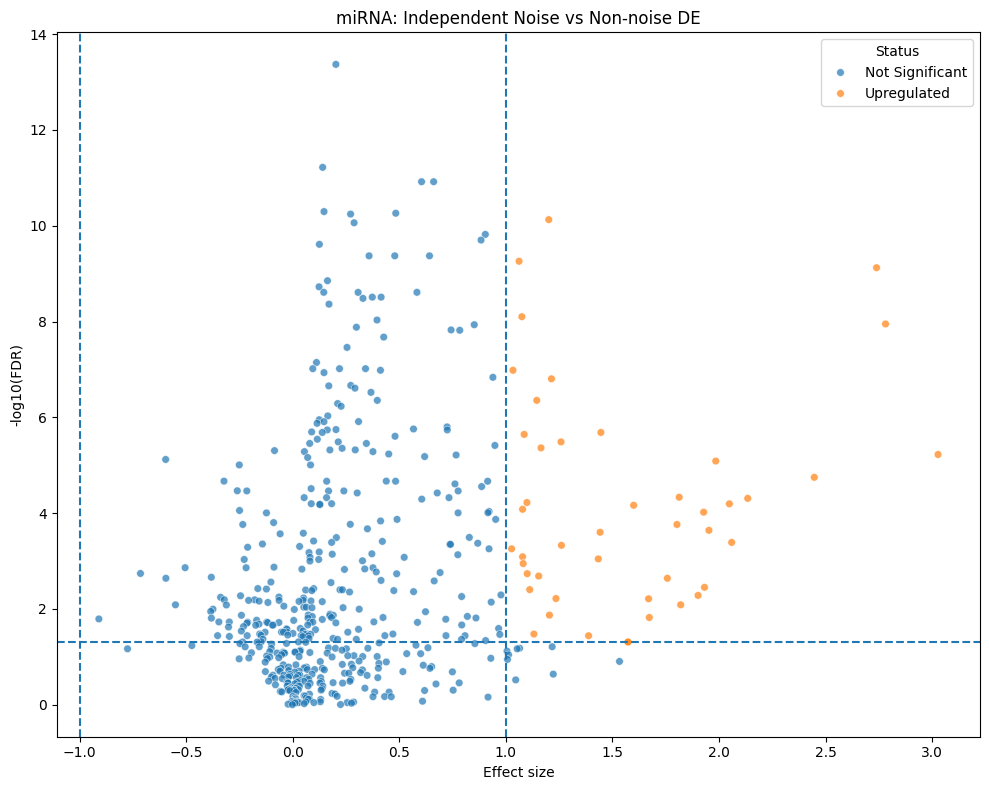

In [39]:
# ============================================================
# STEP 17 : INDEPENDENT VOLCANO PLOT
# ============================================================

plt.figure(
    figsize=(10, 8)
)

plot_df = statistics.copy()

plot_df["neg_log10_FDR"] = (
    -np.log10(
        plot_df["FDR"] + 1e-300
    )
)

sns.scatterplot(
    data=plot_df,
    x="Effect_Size",
    y="neg_log10_FDR",
    hue="Status",
    alpha=0.7,
    s=30
)

plt.axvline(
    x=LOG2FC_THRESHOLD,
    linestyle="--"
)

plt.axvline(
    x=-LOG2FC_THRESHOLD,
    linestyle="--"
)

plt.axhline(
    y=-np.log10(FDR_THRESHOLD),
    linestyle="--"
)

plt.xlabel(
    "Effect size"
)

plt.ylabel(
    "-log10(FDR)"
)

plt.title(
    f"{MODALITY}: Independent Noise vs Non-noise DE"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "M3_Independent_Volcano.png"
    ),
    dpi=300
)

plt.show()

# STEP AF — Heatmap

Selected genes: 46


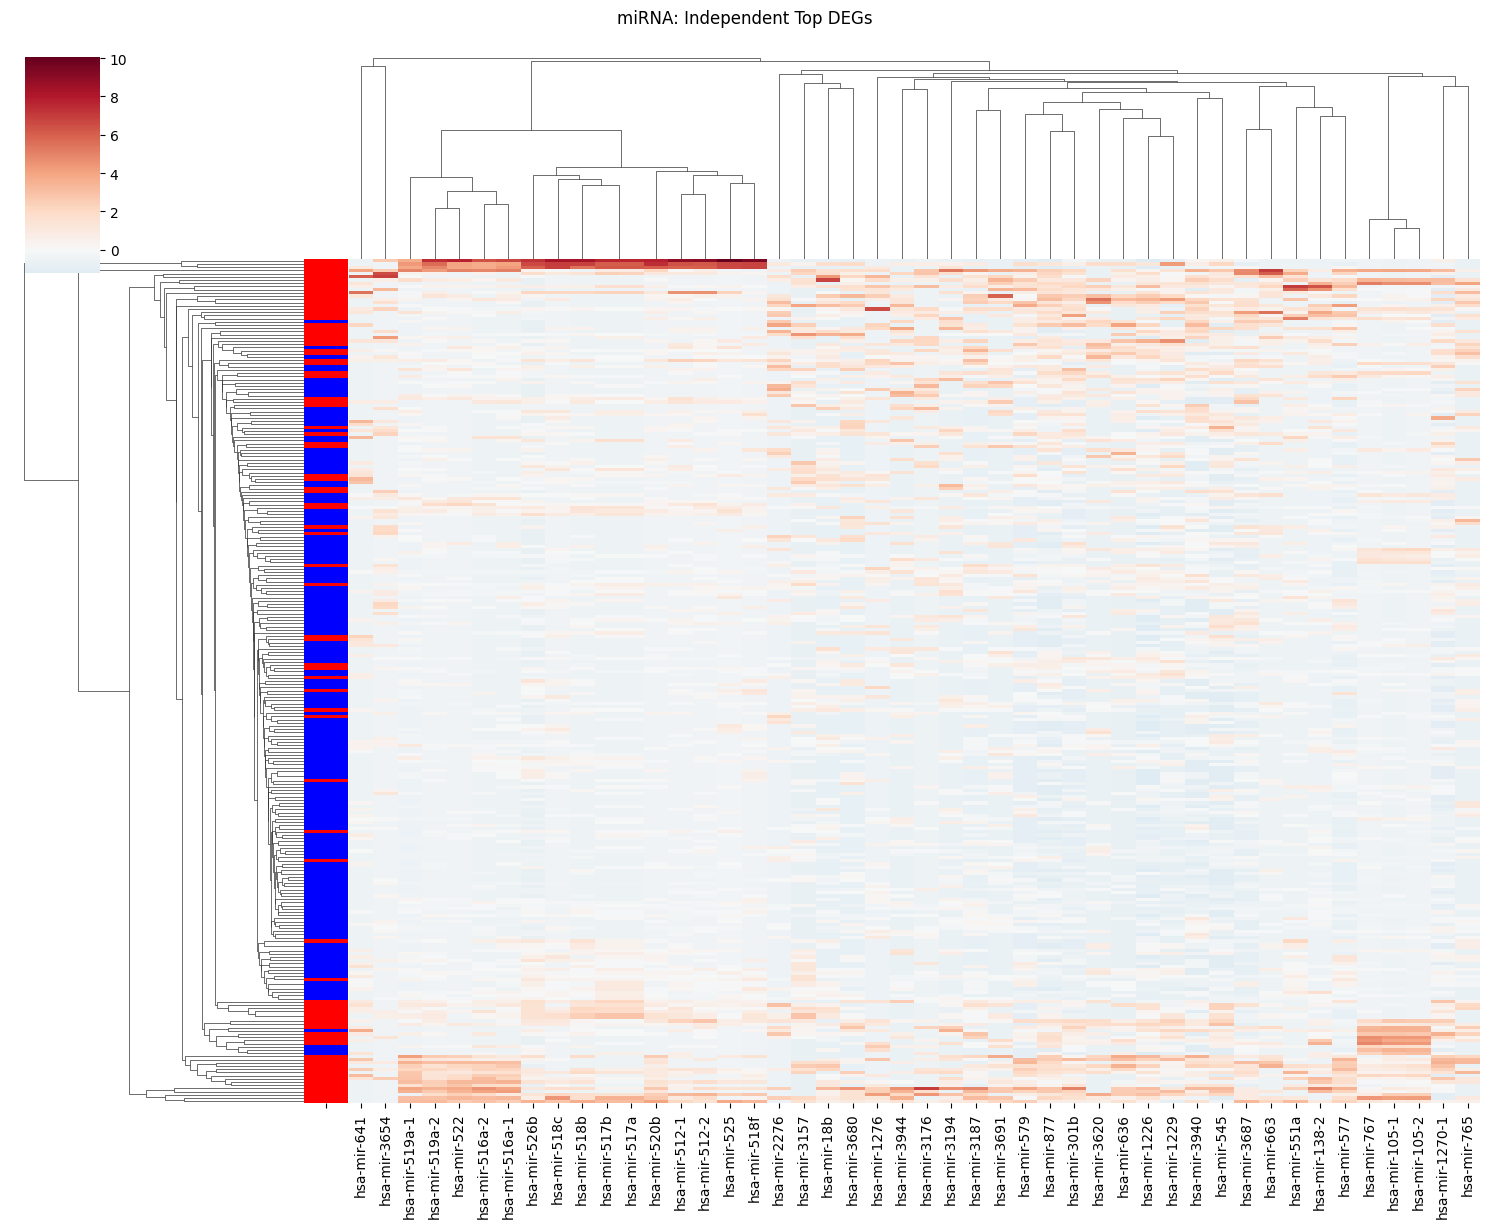

In [40]:
# ============================================================
# STEP 18 : INDEPENDENT TOP-GENE HEATMAP
# ============================================================

top_genes = (
    DEGs
    .head(TOP_N_GENES)
    ["Gene"]
    .tolist()
)

print(
    "Selected genes:",
    len(top_genes)
)

heatmap_expression = (
    inference_expression[
        top_genes
    ]
    .copy()
)

heatmap_groups = np.where(
    inference_labels == -1,
    "Noise",
    "Non-noise"
)

# ------------------------------------------------------------
# Gene-wise z-score
# ------------------------------------------------------------

heatmap_z = (
    heatmap_expression -
    heatmap_expression.mean(axis=0)
) / (
    heatmap_expression.std(axis=0)
    .replace(0, 1)
)

# ------------------------------------------------------------
# Annotation
# ------------------------------------------------------------

row_colors = pd.Series(
    heatmap_groups,
    index=heatmap_expression.index
)

# ------------------------------------------------------------
# Clustered heatmap
# ------------------------------------------------------------

sns.clustermap(
    heatmap_z,

    cmap="RdBu_r",

    center=0,

    row_colors=row_colors.map({
        "Noise": "red",
        "Non-noise": "blue"
    }),

    figsize=(15, 12),

    xticklabels=True,

    yticklabels=False,

    method="average",

    metric="euclidean"
)

plt.suptitle(
    f"{MODALITY}: Independent Top DEGs",
    y=1.02
)

plt.show()

# STEP AG — Biological interpretation

In [41]:
# ============================================================
# STEP 19 : EXPANDED KNOWN CANCER-ASSOCIATED miRNA ANNOTATION
#              FOR miRNA EXPRESSION DATA
# ============================================================

important_miRNAs = {

    # ========================================================
    # 1. ONCO-miRNAs / ONCOMIRS
    # ========================================================

    "OncomiRs": [
        "MIR21",
        "MIR155",
        "MIR10B",
        "MIR17",
        "MIR18A",
        "MIR18B",
        "MIR19A",
        "MIR19B",
        "MIR20A",
        "MIR92A",
        "MIR27A",
        "MIR221",
        "MIR222",
        "MIR301B",
        "MIR372",
        "MIR373",
        "MIR9",
        "MIR96",
        "MIR182",
        "MIR183",
        "MIR191",
        "MIR210",
        "MIR663",
        "MIR520B",
        "MIR522",
        "MIR519A-1",
        "MIR519A-2",
        "MIR519C",
        "MIR525"
    ],

    # ========================================================
    # 2. TUMOR SUPPRESSOR miRNAs
    # ========================================================

    "Tumor_Suppressor_miRNAs": [
        "MIR15A",
        "MIR16-1",
        "MIR16",
        "MIR29A",
        "MIR29B",
        "MIR29C",
        "MIR34A",
        "MIR34B",
        "MIR34C",
        "MIR125A",
        "MIR125B",
        "MIR126",
        "MIR143",
        "MIR145",
        "MIR146A",
        "MIR200A",
        "MIR200B",
        "MIR200C",
        "MIR203A",
        "MIR205",
        "MIR218",
        "MIR375",
        "MIR497",
        "MIR506",
        "MIR508",
        "MIR877"
    ],

    # ========================================================
    # 3. p53-ASSOCIATED miRNAs
    # ========================================================

    "p53_Associated_miRNAs": [
        "MIR34A",
        "MIR34B",
        "MIR34C",
        "MIR145",
        "MIR192",
        "MIR194-2",
        "MIR194",
        "MIR215",
        "MIR107",
        "MIR605",
        "MIR1204",
        "MIR122"
    ],

    # ========================================================
    # 4. CELL CYCLE / PROLIFERATION
    # ========================================================

    "Cell_Cycle_Proliferation": [
        "MIR17",
        "MIR18A",
        "MIR18B",
        "MIR19A",
        "MIR19B",
        "MIR20A",
        "MIR20B",
        "MIR92A",
        "MIR93",
        "MIR106A",
        "MIR106B",
        "MIR221",
        "MIR222",
        "MIR21",
        "MIR31",
        "MIR191",
        "MIR195",
        "MIR497",
        "MIR34A",
        "MIR15A",
        "MIR16",
        "MIR301B",
        "MIR663"
    ],

    # ========================================================
    # 5. PI3K / AKT / MTOR ASSOCIATED miRNAs
    # ========================================================

    "PI3K_AKT_mTOR": [
        "MIR21",
        "MIR29A",
        "MIR29B",
        "MIR29C",
        "MIR126",
        "MIR100",
        "MIR99A",
        "MIR99B",
        "MIR221",
        "MIR222",
        "MIR205",
        "MIR214",
        "MIR486",
        "MIR451A",
        "MIR145",
        "MIR34A",
        "MIR301B"
    ],

    # ========================================================
    # 6. RAS / RAF / MAPK ASSOCIATED miRNAs
    # ========================================================

    "MAPK_RAS_RAF": [
        "MIR21",
        "MIR31",
        "MIR155",
        "MIR221",
        "MIR222",
        "MIR181A",
        "MIR181B",
        "MIR146A",
        "MIR214",
        "MIR10B",
        "MIR17",
        "MIR20A",
        "MIR19A",
        "MIR19B",
        "MIR301B"
    ],

    # ========================================================
    # 7. APOPTOSIS
    # ========================================================

    "Apoptosis": [
        "MIR21",
        "MIR15A",
        "MIR16",
        "MIR29A",
        "MIR29B",
        "MIR29C",
        "MIR34A",
        "MIR34B",
        "MIR34C",
        "MIR125B",
        "MIR146A",
        "MIR155",
        "MIR221",
        "MIR222",
        "MIR24",
        "MIR200C",
        "MIR145",
        "MIR877"
    ],

    # ========================================================
    # 8. EMT / INVASION / METASTASIS
    # ========================================================

    "EMT_Invasion_Metastasis": [
        "MIR21",
        "MIR10B",
        "MIR155",
        "MIR9",
        "MIR23A",
        "MIR27A",
        "MIR31",
        "MIR92A",
        "MIR200A",
        "MIR200B",
        "MIR200C",
        "MIR141",
        "MIR429",
        "MIR205",
        "MIR34A",
        "MIR203A",
        "MIR192",
        "MIR194",
        "MIR375",
        "MIR145",
        "MIR301B"
    ],

    # ========================================================
    # 9. WNT / BETA-CATENIN ASSOCIATED miRNAs
    # ========================================================

    "Wnt_Beta_Catenin": [
        "MIR21",
        "MIR34A",
        "MIR200A",
        "MIR200B",
        "MIR200C",
        "MIR141",
        "MIR429",
        "MIR122",
        "MIR135A",
        "MIR135B",
        "MIR29A",
        "MIR29B",
        "MIR29C",
        "MIR221",
        "MIR222",
        "MIR374A"
    ],

    # ========================================================
    # 10. TGF-BETA ASSOCIATED miRNAs
    # ========================================================

    "TGF_Beta_Signaling": [
        "MIR21",
        "MIR29A",
        "MIR29B",
        "MIR29C",
        "MIR155",
        "MIR200A",
        "MIR200B",
        "MIR200C",
        "MIR141",
        "MIR429",
        "MIR192",
        "MIR194",
        "MIR199A",
        "MIR203A",
        "MIR98",
        "MIR301B"
    ],

    # ========================================================
    # 11. JAK / STAT ASSOCIATED miRNAs
    # ========================================================

    "JAK_STAT_Signaling": [
        "MIR21",
        "MIR155",
        "MIR146A",
        "MIR146B",
        "MIR181A",
        "MIR181B",
        "MIR17",
        "MIR20A",
        "MIR19A",
        "MIR19B",
        "MIR221",
        "MIR222",
        "MIR125B",
        "MIR223",
        "MIR301B"
    ],

    # ========================================================
    # 12. IMMUNE CHECKPOINT / IMMUNE REGULATION
    # ========================================================

    "Immune_Checkpoint": [
        "MIR21",
        "MIR155",
        "MIR146A",
        "MIR146B",
        "MIR34A",
        "MIR200C",
        "MIR200A",
        "MIR200B",
        "MIR126",
        "MIR138",
        "MIR142",
        "MIR181A",
        "MIR181B",
        "MIR223",
        "MIR125B"
    ],

    # ========================================================
    # 13. IMMUNE RESPONSE / INFLAMMATION
    # ========================================================

    "Immune_Response": [
        "MIR21",
        "MIR155",
        "MIR146A",
        "MIR146B",
        "MIR125B",
        "MIR181A",
        "MIR181B",
        "MIR223",
        "MIR132",
        "MIR142",
        "MIR150",
        "MIR34A",
        "MIR29A",
        "MIR29B",
        "MIR29C",
        "MIR199A",
        "MIR138"
    ],

    # ========================================================
    # 14. NF-KB / INFLAMMATION
    # ========================================================

    "NFkB_Inflammation": [
        "MIR21",
        "MIR155",
        "MIR146A",
        "MIR146B",
        "MIR125B",
        "MIR9",
        "MIR132",
        "MIR181A",
        "MIR181B",
        "MIR223",
        "MIR17",
        "MIR20A",
        "MIR31",
        "MIR199A",
        "MIR138"
    ],

    # ========================================================
    # 15. HYPOXIA / ANGIOGENESIS
    # ========================================================

    "Hypoxia_Angiogenesis": [
        "MIR210",
        "MIR21",
        "MIR126",
        "MIR130A",
        "MIR130B",
        "MIR296",
        "MIR17",
        "MIR20A",
        "MIR424",
        "MIR424-5P",
        "MIR519C",
        "MIR92A",
        "MIR16",
        "MIR15A"
    ],

    # ========================================================
    # 16. BREAST CANCER ASSOCIATED miRNAs
    # ========================================================

    "Breast_Cancer_Associated": [
        "MIR21",
        "MIR155",
        "MIR10B",
        "MIR17",
        "MIR18A",
        "MIR19A",
        "MIR19B",
        "MIR20A",
        "MIR92A",
        "MIR200A",
        "MIR200B",
        "MIR200C",
        "MIR141",
        "MIR429",
        "MIR205",
        "MIR145",
        "MIR34A",
        "MIR125B",
        "MIR221",
        "MIR222",
        "MIR210",
        "MIR182",
        "MIR183",
        "MIR96",
        "MIR375",
        "MIR301B",
        "MIR520B",
        "MIR522",
        "MIR519A-1",
        "MIR519A-2",
        "MIR525"
    ],

    # ========================================================
    # 17. BREAST CANCER PROLIFERATION
    # ========================================================

    "Breast_Cancer_Proliferation": [
        "MIR21",
        "MIR155",
        "MIR221",
        "MIR222",
        "MIR17",
        "MIR18A",
        "MIR19A",
        "MIR19B",
        "MIR20A",
        "MIR92A",
        "MIR93",
        "MIR106B",
        "MIR191",
        "MIR210",
        "MIR9",
        "MIR31",
        "MIR27A",
        "MIR23A",
        "MIR301B",
        "MIR520B",
        "MIR522"
    ],

    # ========================================================
    # 18. ESTROGEN RECEPTOR / HORMONE SIGNALING
    # ========================================================

    "Estrogen_Receptor_Signaling": [
        "MIR21",
        "MIR10B",
        "MIR17",
        "MIR18A",
        "MIR19A",
        "MIR19B",
        "MIR20A",
        "MIR92A",
        "MIR221",
        "MIR222",
        "MIR206",
        "MIR145",
        "MIR200A",
        "MIR200B",
        "MIR200C",
        "MIR141",
        "MIR429",
        "MIR375"
    ],

    # ========================================================
    # 19. HER2 / ERBB ASSOCIATED miRNAs
    # ========================================================

    "HER2_ERBB_Signaling": [
        "MIR21",
        "MIR155",
        "MIR221",
        "MIR222",
        "MIR125A",
        "MIR125B",
        "MIR205",
        "MIR200C",
        "MIR200A",
        "MIR200B",
        "MIR141",
        "MIR429",
        "MIR375",
        "MIR34A",
        "MIR301B"
    ],

    # ========================================================
    # 20. DNA DAMAGE / DNA REPAIR ASSOCIATED miRNAs
    # ========================================================

    "DNA_Damage_DNA_Repair": [
        "MIR21",
        "MIR24",
        "MIR34A",
        "MIR34B",
        "MIR34C",
        "MIR16",
        "MIR15A",
        "MIR29A",
        "MIR29B",
        "MIR29C",
        "MIR96",
        "MIR138",
        "MIR146A",
        "MIR155",
        "MIR182",
        "MIR183",
        "MIR421",
        "MIR124",
        "MIR877"
    ],

    # ========================================================
    # 21. CELLULAR SENESCENCE
    # ========================================================

    "Cellular_Senescence": [
        "MIR21",
        "MIR34A",
        "MIR29A",
        "MIR29B",
        "MIR29C",
        "MIR146A",
        "MIR146B",
        "MIR181A",
        "MIR181B",
        "MIR203A",
        "MIR200C",
        "MIR15A",
        "MIR16",
        "MIR24",
        "MIR125B"
    ],

    # ========================================================
    # 22. CANCER STEM CELL / SELF-RENEWAL
    # ========================================================

    "Cancer_Stem_Cell": [
        "MIR21",
        "MIR155",
        "MIR34A",
        "MIR200A",
        "MIR200B",
        "MIR200C",
        "MIR141",
        "MIR429",
        "MIR205",
        "MIR29A",
        "MIR29B",
        "MIR29C",
        "MIR17",
        "MIR20A",
        "MIR92A",
        "MIR9",
        "MIR10B",
        "MIR181A",
        "MIR181B",
        "MIR221",
        "MIR222",
        "MIR301B"
    ],

    # ========================================================
    # 23. NOTCH SIGNALING
    # ========================================================

    "Notch_Signaling": [
        "MIR21",
        "MIR34A",
        "MIR146A",
        "MIR155",
        "MIR181A",
        "MIR181B",
        "MIR199A",
        "MIR200C",
        "MIR200A",
        "MIR200B",
        "MIR141",
        "MIR429",
        "MIR221",
        "MIR222"
    ],

    # ========================================================
    # 24. MYC ASSOCIATED miRNAs
    # ========================================================

    "MYC_Signaling": [
        "MIR17",
        "MIR18A",
        "MIR19A",
        "MIR19B",
        "MIR20A",
        "MIR92A",
        "MIR21",
        "MIR221",
        "MIR222",
        "MIR9",
        "MIR10B",
        "MIR27A",
        "MIR23A",
        "MIR106A",
        "MIR106B",
        "MIR93",
        "MIR301B"
    ],

    # ========================================================
    # 25. EMT / EPITHELIAL-MESENCHYMAL TRANSITION
    # ========================================================

    "EMT_Regulation": [
        "MIR200A",
        "MIR200B",
        "MIR200C",
        "MIR141",
        "MIR429",
        "MIR205",
        "MIR34A",
        "MIR34B",
        "MIR34C",
        "MIR21",
        "MIR10B",
        "MIR9",
        "MIR31",
        "MIR23A",
        "MIR27A",
        "MIR155",
        "MIR192",
        "MIR194",
        "MIR301B"
    ],

    # ========================================================
    # 26. METASTASIS / INVASION
    # ========================================================

    "Metastasis_Invasion": [
        "MIR10B",
        "MIR21",
        "MIR155",
        "MIR9",
        "MIR23A",
        "MIR27A",
        "MIR31",
        "MIR92A",
        "MIR200C",
        "MIR200B",
        "MIR200A",
        "MIR141",
        "MIR429",
        "MIR205",
        "MIR375",
        "MIR145",
        "MIR34A",
        "MIR301B"
    ],

    # ========================================================
    # 27. ANGIOGENESIS
    # ========================================================

    "Angiogenesis": [
        "MIR21",
        "MIR126",
        "MIR210",
        "MIR130A",
        "MIR130B",
        "MIR296",
        "MIR17",
        "MIR20A",
        "MIR92A",
        "MIR221",
        "MIR222",
        "MIR424",
        "MIR16"
    ],

    # ========================================================
    # 28. METABOLIC REPROGRAMMING
    # ========================================================

    "Cancer_Metabolism": [
        "MIR21",
        "MIR155",
        "MIR210",
        "MIR122",
        "MIR23A",
        "MIR27A",
        "MIR199A",
        "MIR451A",
        "MIR125B",
        "MIR143",
        "MIR145",
        "MIR33A",
        "MIR33B",
        "MIR34A"
    ],

    # ========================================================
    # 29. BREAST / OVARIAN CANCER ASSOCIATED miRNAs
    # ========================================================

    "Breast_Ovarian_Cancer": [
        "MIR21",
        "MIR155",
        "MIR10B",
        "MIR17",
        "MIR18A",
        "MIR19A",
        "MIR19B",
        "MIR20A",
        "MIR92A",
        "MIR200A",
        "MIR200B",
        "MIR200C",
        "MIR141",
        "MIR429",
        "MIR205",
        "MIR34A",
        "MIR125B",
        "MIR221",
        "MIR222",
        "MIR210",
        "MIR145",
        "MIR182",
        "MIR183",
        "MIR96",
        "MIR375",
        "MIR301B",
        "MIR520B",
        "MIR522",
        "MIR519A-1",
        "MIR519A-2",
        "MIR525"
    ],

    # ========================================================
    # 30. GENERAL CANCER miRNA BIOMARKERS
    # ========================================================

    "Cancer_Biomarkers": [
        "MIR21",
        "MIR155",
        "MIR10B",
        "MIR17",
        "MIR18A",
        "MIR18B",
        "MIR19A",
        "MIR19B",
        "MIR20A",
        "MIR92A",
        "MIR34A",
        "MIR125B",
        "MIR126",
        "MIR145",
        "MIR200A",
        "MIR200B",
        "MIR200C",
        "MIR205",
        "MIR210",
        "MIR221",
        "MIR222",
        "MIR375",
        "MIR451A",
        "MIR122",
        "MIR146A",
        "MIR182",
        "MIR183",
        "MIR96",
        "MIR301B",
        "MIR520B",
        "MIR522",
        "MIR519A-1",
        "MIR519A-2",
        "MIR519C",
        "MIR525",
        "MIR663",
        "MIR877"
    ],

    # ========================================================
    # 31. STUDY-IDENTIFIED DIFFERENTIALLY EXPRESSED miRNAs
    #
    # These are the miRNAs present in the supplied DEG table.
    #
    # This category is intentionally separate from pathway
    # categories. It records that the miRNA was identified in
    # the current analysis without automatically claiming a
    # specific biological pathway.
    # ========================================================

    "Study_DEG_Identified_miRNAs": [
        "MIR877",
        "MIR3940",
        "MIR1229",
        "MIR301B",
        "MIR520B",
        "MIR579",
        "MIR519A-2",
        "MIR663",
        "MIR3664",
        "MIR105-2",
        "MIR522",
        "MIR3687",
        "MIR3187",
        "MIR18B",
        "MIR512-1",
        "MIR1276",
        "MIR3680",
        "MIR105-1",
        "MIR138-2",
        "MIR3944",
        "MIR3157",
        "MIR516A-2",
        "MIR577",
        "MIR3194",
        "MIR636",
        "MIR570",
        "MIR3691",
        "MIR2276",
        "MIR519A-1",
        "MIR3620",
        "MIR1269",
        "MIR320E",
        "MIR551A",
        "MIR767",
        "MIR512-2",
        "MIR516A-1",
        "MIR641",
        "MIR525",
        "MIR3176",
        "MIR3667"
    ]
}


# ============================================================
# miRNA NORMALIZATION FUNCTION
# ============================================================

def normalize_mirna_id(mirna):
    """
    Normalize miRNA identifiers so that common representations
    can be compared.

    Examples:

        hsa-miR-21       -> MIR21
        miR-21           -> MIR21
        MIR21            -> MIR21
        hsa-mir-105-1    -> MIR1051
        MIR105-1         -> MIR1051
        hsa-miR-18b      -> MIR18B
    """

    return (
        str(mirna)
        .strip()
        .upper()
        .replace("HSA-", "")
        .replace("MIR-", "MIR")
        .replace("-", "")
    )


# ============================================================
# PREPARE DEG GENE IDENTIFIERS ONCE
# ============================================================

DEGs = DEGs.copy()

DEGs["Gene_Normalized"] = (
    DEGs["Gene"]
    .astype(str)
    .apply(normalize_mirna_id)
)


# ============================================================
# PERFORM miRNA ANNOTATION
# ============================================================

biological_hits = []


for pathway, mirnas in important_miRNAs.items():

    for mirna in mirnas:

        # ----------------------------------------------------
        # Normalize dictionary miRNA identifier
        # ----------------------------------------------------

        mirna_normalized = normalize_mirna_id(mirna)

        # ----------------------------------------------------
        # Find matching DEG
        # ----------------------------------------------------

        hits = DEGs[
            DEGs["Gene_Normalized"]
            .eq(mirna_normalized)
        ]

        # ----------------------------------------------------
        # Store annotation
        # ----------------------------------------------------

        if not hits.empty:

            temp = hits.copy()

            temp["Known_Biological_Category"] = pathway
            temp["Known_miRNA"] = mirna

            biological_hits.append(temp)


# ============================================================
# COMBINE RESULTS
# ============================================================

if biological_hits:

    biological_hits = pd.concat(
        biological_hits,
        ignore_index=True
    )

    # --------------------------------------------------------
    # Remove temporary normalization column
    # --------------------------------------------------------

    if "Gene_Normalized" in biological_hits.columns:

        biological_hits = biological_hits.drop(
            columns=["Gene_Normalized"]
        )

    # --------------------------------------------------------
    # Sort by FDR
    # --------------------------------------------------------

    biological_hits = (
        biological_hits
        .sort_values(
            "FDR",
            ascending=True
        )
        .reset_index(drop=True)
    )

else:

    biological_hits = pd.DataFrame()


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("KNOWN CANCER-ASSOCIATED miRNA ANNOTATION")
print("=" * 80)

print(
    "Number of annotated records:",
    len(biological_hits)
)


if not biological_hits.empty:

    print(
        "Unique miRNAs:",
        biological_hits[
            "Known_miRNA"
        ].nunique()
    )

    print(
        "Biological categories:",
        biological_hits[
            "Known_Biological_Category"
        ].nunique()
    )

    print("\nTop annotated miRNAs:")

    print(
        biological_hits.head(30).to_string(
            index=False
        )
    )

else:

    print(
        "No known cancer-associated miRNAs were detected."
    )


# ============================================================
# ADDITIONAL SUMMARY:
# UNIQUE STUDY miRNAs DETECTED
# ============================================================

print("\n" + "=" * 80)
print("STUDY-IDENTIFIED DIFFERENTIALLY EXPRESSED miRNAs")
print("=" * 80)


study_mirnas = important_miRNAs[
    "Study_DEG_Identified_miRNAs"
]


study_mirnas_normalized = {
    normalize_mirna_id(x)
    for x in study_mirnas
}


detected_study_mirnas = DEGs[
    DEGs["Gene_Normalized"].isin(
        study_mirnas_normalized
    )
].copy()


print(
    "Number of study miRNAs in DEG table:",
    len(detected_study_mirnas)
)


if not detected_study_mirnas.empty:

    print("\nDetected study miRNAs:")

    print(
        detected_study_mirnas[
            [
                "Gene",
                "U_Statistic",
                "P_Value",
                "FDR",
                "Effect_Size",
                "Status"
            ]
        ].to_string(index=False)
    )


# ============================================================
# CHECK FOR SIGNIFICANT miRNAs NOT YET ANNOTATED
# ============================================================

print("\n" + "=" * 80)
print("ANNOTATION COVERAGE CHECK")
print("=" * 80)


annotated_normalized = set(
    biological_hits["Gene"]
    .astype(str)
    .apply(normalize_mirna_id)
) if not biological_hits.empty else set()


all_deg_normalized = set(
    DEGs["Gene_Normalized"]
)


unannotated_degs = DEGs[
    ~DEGs["Gene_Normalized"].isin(
        annotated_normalized
    )
].copy()


if not unannotated_degs.empty:

    print(
        "DEG records without a biological annotation:",
        len(unannotated_degs)
    )

    print("\nUnannotated DEGs:")

    print(
        unannotated_degs[
            [
                "Gene",
                "U_Statistic",
                "P_Value",
                "FDR",
                "Effect_Size",
                "Status"
            ]
        ].to_string(index=False)
    )

else:

    print(
        "All DEGs have at least one annotation."
    )


# ============================================================
# SAVE MAIN ANNOTATION RESULT
# ============================================================

output_file = os.path.join(
    OUTPUT_DIR,
    "Known_Cancer_miRNA_Annotation.csv"
)


biological_hits.to_csv(
    output_file,
    index=False
)


print("\nSaved to:")
print(output_file)


# ============================================================
# SAVE STUDY miRNA RESULTS SEPARATELY
# ============================================================

study_output_file = os.path.join(
    OUTPUT_DIR,
    "Study_DEG_Identified_miRNAs.csv"
)


detected_study_mirnas.drop(
    columns=["Gene_Normalized"],
    errors="ignore"
).to_csv(
    study_output_file,
    index=False
)


print("\nStudy miRNA results saved to:")
print(study_output_file)


# ============================================================
# SAVE UNANNOTATED DEG RESULTS
# ============================================================

unannotated_output_file = os.path.join(
    OUTPUT_DIR,
    "Unannotated_DEG_miRNAs.csv"
)


unannotated_degs.drop(
    columns=["Gene_Normalized"],
    errors="ignore"
).to_csv(
    unannotated_output_file,
    index=False
)


print("\nUnannotated DEG results saved to:")
print(unannotated_output_file)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL miRNA ANNOTATION SUMMARY")
print("=" * 80)

print(
    "Total DEGs:",
    len(DEGs)
)

print(
    "Study-identified miRNAs:",
    len(study_mirnas)
)

print(
    "Study miRNAs detected:",
    len(detected_study_mirnas)
)

print(
    "Annotated records:",
    len(biological_hits)
)

if not biological_hits.empty:

    print(
        "Unique annotated miRNAs:",
        biological_hits[
            "Known_miRNA"
        ].nunique()
    )

    print(
        "Unique biological categories:",
        biological_hits[
            "Known_Biological_Category"
        ].nunique()
    )

print("=" * 80)



KNOWN CANCER-ASSOCIATED miRNA ANNOTATION
Number of annotated records: 83
Unique miRNAs: 35
Biological categories: 20

Top annotated miRNAs:
          Gene  U_Statistic      P_Value          FDR  Effect_Size      Status   Known_Biological_Category Known_miRNA
   hsa-mir-877      11934.5 1.186746e-12 7.461666e-11     1.201513 Upregulated                   Apoptosis      MIR877
   hsa-mir-877      11934.5 1.186746e-12 7.461666e-11     1.201513 Upregulated     Tumor_Suppressor_miRNAs      MIR877
   hsa-mir-877      11934.5 1.186746e-12 7.461666e-11     1.201513 Upregulated       DNA_Damage_DNA_Repair      MIR877
   hsa-mir-877      11934.5 1.186746e-12 7.461666e-11     1.201513 Upregulated           Cancer_Biomarkers      MIR877
   hsa-mir-877      11934.5 1.186746e-12 7.461666e-11     1.201513 Upregulated Study_DEG_Identified_miRNAs      MIR877
  hsa-mir-520b      11231.5 2.543363e-11 7.525363e-10     2.739359 Upregulated Breast_Cancer_Proliferation     MIR520B
  hsa-mir-520b      11231.

# STEP AH — GO enrichment

In [42]:
# ============================================================
# STEP 20 : GO ENRICHMENT
# ============================================================
!pip install gseapy
import gseapy as gp

gene_list = (
    DEGs["Gene"]
    .astype(str)
    .str.split("|")
    .str[0]
    .drop_duplicates()
    .tolist()
)

print(
    "Genes for GO:",
    len(gene_list)
)

go_results = gp.enrichr(
    gene_list=gene_list,

    gene_sets=[
        "GO_Biological_Process_2026",
        "GO_Molecular_Function_2026",
        "GO_Cellular_Component_2026"
    ],

    organism="human",

    outdir=None,

    no_plot=True,

    cutoff=1.0
)

if not go_results.results.empty:

    go_table = go_results.results.copy()

    go_table.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "M3_GO_Enrichment.csv"
        ),
        index=False
    )

    print(
        go_table.head(20)
    )

else:

    print(
        "No enriched GO terms."
    )

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 2.3 MB/s eta 0:00:00
Genes for GO: 46
No enriched GO terms.


# STEP AI — KEGG

In [43]:
# ============================================================
# STEP 21 : KEGG ENRICHMENT
# ============================================================

kegg_results = gp.enrichr(
    gene_list=gene_list,

    gene_sets="KEGG_2021_Human",

    organism="human",

    outdir=None,

    no_plot=True,

    cutoff=1.0
)

kegg_table = kegg_results.results.copy()

kegg_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "M3_KEGG_Enrichment.csv"
    ),
    index=False
)

print(
    kegg_table.head(20)
)

Empty DataFrame
Columns: [Gene_set, Term, Overlap, P-value, Adjusted P-value, Old P-value, Old Adjusted P-value, Odds Ratio, Combined Score, Genes]
Index: []


# PART AJ — M4: competing non-deep baseline


PCA + LOF
PCA + Isolation Forest
DAE + HDBSCAN

# STEP 22 — PCA + LOF

In [44]:
# ============================================================
# STEP 22 : BASELINE 1 — PCA + LOF
# ============================================================

from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination="auto"
)

lof_labels = lof.fit_predict(
    X_test_pca
)

lof_noise = (
    lof_labels == -1
)

print("=" * 80)

print("PCA + LOF")

print(
    "Noise:",
    lof_noise.sum()
)

print(
    "Noise %:",
    lof_noise.mean() * 100
)

PCA + LOF
Noise: 5
Noise %: 3.787878787878788


# STEP AK — Isolation Forest

In [45]:
# ============================================================
# STEP 23 : BASELINE 2 — PCA + ISOLATION FOREST
# ============================================================

from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=300,
    random_state=SEED,
    contamination="auto"
)

iso_labels = iso.fit_predict(
    X_test_pca
)

iso_noise = (
    iso_labels == -1
)

print("=" * 80)

print("PCA + Isolation Forest")

print(
    "Noise:",
    iso_noise.sum()
)

print(
    "Noise %:",
    iso_noise.mean() * 100
)

PCA + Isolation Forest
Noise: 11
Noise %: 8.333333333333332


# STEP AL — Baseline comparison

In [46]:
# ============================================================
# STEP 24 : M4 BASELINE COMPARISON
# ============================================================

baseline_results = pd.DataFrame({

    "Method": [
        f"PCA-{matched_rank} + HDBSCAN",
        f"PCA-{matched_rank} + LOF",
        f"PCA-{matched_rank} + Isolation Forest"
    ],

    "Noise_Samples": [
        raw_summary["Noise_Samples"],
        int(lof_noise.sum()),
        int(iso_noise.sum())
    ],

    "Noise_Percent": [
        raw_summary["Noise_Percent"],
        lof_noise.mean() * 100,
        iso_noise.mean() * 100
    ],

    "Clusters_K": [
        raw_summary["Clusters_K"],
        np.nan,
        np.nan
    ]
})

print(
    baseline_results
)

baseline_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "M4_Baseline_Outlier_Comparison.csv"
    ),
    index=False
)

                      Method  Noise_Samples  Noise_Percent  Clusters_K
0           PCA-29 + HDBSCAN             83      62.878788         2.0
1               PCA-29 + LOF              5       3.787879         NaN
2  PCA-29 + Isolation Forest             11       8.333333         NaN


# STEP AM — M4 synthetic technical-noise experiment

We can create controlled noise:

Clean expression
      ↓
inject Gaussian technical noise
      ↓
DAE
      ↓
outlier detection
      ↓
measure recovery

In [47]:
# ============================================================
# STEP 25 : M4 SYNTHETIC TECHNICAL NOISE
# ============================================================

def inject_gaussian_noise(
    X,
    noise_level,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )

    noise = rng.normal(
        loc=0.0,
        scale=noise_level,
        size=X.shape
    )

    return X + noise

In [48]:
# ============================================================
# STEP 25.1 : TEST MULTIPLE NOISE LEVELS
# ============================================================

noise_levels = [
    0.10,
    0.25,
    0.50,
    1.00
]

simulation_results = []

for level in noise_levels:

    X_noisy = inject_gaussian_noise(
        X_test_scaled,
        noise_level=level,
        random_state=SEED
    )

    reconstruction = dae_mse.predict(
        X_noisy,
        verbose=0
    )

    residual = np.mean(
        np.abs(
            X_noisy -
            reconstruction
        ),
        axis=1
    )

    simulation_results.append({

        "Noise_Level":
            level,

        "Mean_Residual":
            residual.mean(),

        "Median_Residual":
            np.median(residual),

        "Max_Residual":
            residual.max()

    })

simulation_results = pd.DataFrame(
    simulation_results
)

print(
    simulation_results
)

simulation_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "M4_Synthetic_Technical_Noise.csv"
    ),
    index=False
)

   Noise_Level  Mean_Residual  Median_Residual  Max_Residual
0         0.10       0.562846         0.542557      1.101337
1         0.25       0.595035         0.571071      1.122346
2         0.50       0.695723         0.666368      1.183626
3         1.00       0.989361         0.968463      1.392631


# PART AN — M4: HDBSCAN Noise vs Dataset Labels
PART AN.1 — Configuration

In [49]:
# ============================================================
# PART AN.1 — M4 CONFIGURATION
# HDBSCAN Noise vs Dataset Labels
# ============================================================

import os
import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

LABEL_FILE = "/content/labels.csv"

RESULTS_DIR = "/content/M4_Label_Noise_Analysis"
os.makedirs(RESULTS_DIR, exist_ok=True)

LABEL_COLUMN = 0

NOISE_LABEL = -1

ALPHA = 0.05

print("=" * 70)
print("PART AN.1 — M4 CONFIGURATION")
print("=" * 70)

print("Label file:", LABEL_FILE)
print("Results directory:", RESULTS_DIR)
print("Significance level:", ALPHA)

PART AN.1 — M4 CONFIGURATION
Label file: /content/labels.csv
Results directory: /content/M4_Label_Noise_Analysis
Significance level: 0.05


# PART AN.2 — Load labels.csv

In [50]:
# ============================================================
# PART AN.2 — LOAD DATASET LABELS
# ============================================================

labels_df = pd.read_csv(
    LABEL_FILE,
    header=None
)

labels = labels_df.iloc[:, LABEL_COLUMN].copy()

# Convert to numeric
labels = pd.to_numeric(
    labels,
    errors="coerce"
)

# Check missing labels
missing_labels = labels.isna().sum()

if missing_labels > 0:
    raise ValueError(
        f"Found {missing_labels} missing labels in labels.csv."
    )

# Convert to integer
labels = labels.astype(int)

print("=" * 70)
print("PART AN.2 — LABEL INFORMATION")
print("=" * 70)

print("Number of labels:", len(labels))
print("\nLabel distribution:")
print(labels.value_counts().sort_index())

print("\nUnique labels:")
print(sorted(labels.unique()))

PART AN.2 — LABEL INFORMATION
Number of labels: 875

Label distribution:
0
0    115
1    131
2     46
3    436
4    147
Name: count, dtype: int64

Unique labels:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


# PART AN.3 — Validate Labels Against Your Dataset

In [51]:
# ============================================================
# PART AN.3 — VALIDATE LABEL LENGTH
# ============================================================

EXPECTED_SAMPLES = 875

print("=" * 70)
print("PART AN.3 — LABEL/DATASET VALIDATION")
print("=" * 70)

if len(labels) != EXPECTED_SAMPLES:
    raise ValueError(
        f"Expected {EXPECTED_SAMPLES} labels, "
        f"but labels.csv contains {len(labels)} labels."
    )

print("✓ Label count:", len(labels))
print("✓ Expected samples:", EXPECTED_SAMPLES)
print("✓ Label count matches dataset.")

PART AN.3 — LABEL/DATASET VALIDATION
✓ Label count: 875
✓ Expected samples: 875
✓ Label count matches dataset.


# PART AN.4 — Convert HDBSCAN Labels to Noise/Clustered

In [52]:
# ============================================================
# PART AN.4 — HDBSCAN NOISE/CLUSTERED CONVERSION
# ============================================================

def create_noise_status(hdbscan_labels):
    """
    Convert HDBSCAN cluster labels into:
        Noise    -> -1
        Clustered -> any cluster label >= 0
    """

    hdbscan_labels = np.asarray(hdbscan_labels)

    noise_status = np.where(
        hdbscan_labels == NOISE_LABEL,
        "Noise",
        "Clustered"
    )

    return noise_status

# PART AN.5 — Cramér's V Function

In [53]:
# ============================================================
# PART AN.5 — CRAMÉR'S V
# ============================================================

def cramers_v(contingency_table):
    """
    Calculate Cramér's V from a contingency table.
    """

    chi2, p, dof, expected = chi2_contingency(
        contingency_table
    )

    n = contingency_table.to_numpy().sum()

    r, k = contingency_table.shape

    denominator = min(
        k - 1,
        r - 1
    )

    if denominator <= 0 or n == 0:
        return np.nan

    return np.sqrt(
        (chi2 / n) / denominator
    )

# PART AN.6 — Standardized Residuals Function

In [54]:
# ============================================================
# PART AN.6 — STANDARDIZED RESIDUALS
# ============================================================

def standardized_residuals(contingency_table):
    """
    Calculate Pearson standardized residuals.

    Residual > 0:
        observed count > expected count

    Residual < 0:
        observed count < expected count
    """

    chi2, p, dof, expected = chi2_contingency(
        contingency_table
    )

    observed = contingency_table.to_numpy(dtype=float)

    row_totals = observed.sum(axis=1, keepdims=True)
    col_totals = observed.sum(axis=0, keepdims=True)
    total = observed.sum()

    expected_prob = (
        expected / total
    )

    row_prob = row_totals / total
    col_prob = col_totals / total

    denominator = np.sqrt(
        expected
        * (1 - row_prob)
        * (1 - col_prob)
    )

    residuals = (
        observed - expected
    ) / denominator

    return pd.DataFrame(
        residuals,
        index=contingency_table.index,
        columns=contingency_table.columns
    )

# PART AN.7 — Fisher's Exact Test Helper

In [55]:
# ============================================================
# PART AN.7 — FISHER'S EXACT TEST FOR EACH LABEL
# ============================================================

def fisher_tests_by_label(labels, noise_status):

    temp = pd.DataFrame({
        "Label": labels.values,
        "Noise_Status": noise_status
    })

    results = []

    unique_labels = sorted(
        temp["Label"].unique()
    )

    for label in unique_labels:

        temp["Target_Label"] = (
            temp["Label"] == label
        )

        table = pd.crosstab(
            temp["Target_Label"],
            temp["Noise_Status"]
        )

        # Ensure 2x2 structure
        for row in [False, True]:
            if row not in table.index:
                table.loc[row] = 0

        for col in ["Clustered", "Noise"]:
            if col not in table.columns:
                table[col] = 0

        table = table.loc[
            [False, True],
            ["Clustered", "Noise"]
        ]

        odds_ratio, p_value = fisher_exact(
            table
        )

        results.append({
            "Label": label,
            "Odds_Ratio": odds_ratio,
            "Fisher_P_Value": p_value
        })

    return pd.DataFrame(results)

# PART AN.8 — Main M4 Analysis Function

In [56]:

# ============================================================
# PART AN.8 — M4 LABEL–NOISE ANALYSIS FUNCTION
#                Methylation / mRNA / miRNA
#
# Supports:
#   - Full-sample HDBSCAN labels
#   - Held-out/inference HDBSCAN labels
#   - Automatic sample-index alignment
#
# Statistical tests:
#   1. Chi-square
#   2. Cramér's V
#   3. Adjusted standardized Pearson residuals
#   4. Label-wise Fisher exact tests
#   5. Benjamini-Hochberg FDR
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests


# ============================================================
# Cramér's V
# ============================================================

def cramers_v(contingency_table):

    chi2, _, _, _ = chi2_contingency(
        contingency_table
    )

    n = contingency_table.to_numpy().sum()

    r, k = contingency_table.shape

    if n <= 1:
        return np.nan

    phi2 = chi2 / n

    phi2_corrected = max(
        0,
        phi2 -
        ((k - 1) * (r - 1)) / (n - 1)
    )

    r_corrected = (
        r -
        ((r - 1) ** 2) / (n - 1)
    )

    k_corrected = (
        k -
        ((k - 1) ** 2) / (n - 1)
    )

    denominator = min(
        k_corrected - 1,
        r_corrected - 1
    )

    if denominator <= 0:
        return np.nan

    return np.sqrt(
        phi2_corrected / denominator
    )


# ============================================================
# M4 ANALYSIS
# ============================================================

def run_m4_label_noise_analysis(
    modality,
    hdbscan_labels,
    dataset_labels,
    sample_indices=None
):

    print("\n" + "=" * 80)
    print(
        f"M4 LABEL–NOISE ANALYSIS — {modality}"
    )
    print("=" * 80)

    # ========================================================
    # Convert inputs
    # ========================================================

    dataset_labels = pd.Series(
        dataset_labels
    ).reset_index(drop=True)

    hdbscan_labels = pd.Series(
        hdbscan_labels
    ).reset_index(drop=True)

    print("\nInput dimensions")
    print("-" * 80)

    print(
        f"Dataset labels : {len(dataset_labels)}"
    )

    print(
        f"HDBSCAN labels : {len(hdbscan_labels)}"
    )

    # ========================================================
    # FULL DATASET
    # ========================================================

    if sample_indices is None:

        if len(hdbscan_labels) != len(dataset_labels):

            raise ValueError(
                f"\n{modality}: Length mismatch.\n\n"
                f"HDBSCAN labels = "
                f"{len(hdbscan_labels)}\n"
                f"Dataset labels = "
                f"{len(dataset_labels)}\n\n"
                "HDBSCAN appears to have been "
                "generated on a subset.\n"
                "Provide the corresponding "
                "sample_indices."
            )

        aligned_hdbscan = (
            hdbscan_labels.copy()
        )

        aligned_dataset = (
            dataset_labels.copy()
        )

        aligned_indices = np.arange(
            len(dataset_labels)
        )

    # ========================================================
    # SUBSET / INFERENCE DATASET
    # ========================================================

    else:

        sample_indices = np.asarray(
            sample_indices
        )

        if len(hdbscan_labels) != len(sample_indices):

            raise ValueError(
                f"\n{modality}: HDBSCAN labels and "
                f"sample_indices mismatch.\n\n"
                f"HDBSCAN labels = "
                f"{len(hdbscan_labels)}\n"
                f"sample_indices = "
                f"{len(sample_indices)}"
            )

        if np.any(sample_indices < 0):

            raise ValueError(
                f"{modality}: Negative sample index detected."
            )

        if np.any(
            sample_indices >= len(dataset_labels)
        ):

            raise ValueError(
                f"{modality}: sample_indices contains "
                "an index outside the dataset."
            )

        aligned_hdbscan = (
            hdbscan_labels.copy()
        )

        aligned_dataset = (
            dataset_labels.iloc[
                sample_indices
            ]
            .reset_index(drop=True)
        )

        aligned_indices = sample_indices

        print("\nSubset alignment enabled.")
        print(
            f"Aligned samples : "
            f"{len(aligned_hdbscan)}"
        )

    # ========================================================
    # Remove missing observations
    # ========================================================

    valid_mask = (
        aligned_hdbscan.notna()
        &
        aligned_dataset.notna()
    )

    aligned_hdbscan = (
        aligned_hdbscan[
            valid_mask
        ]
        .reset_index(drop=True)
    )

    aligned_dataset = (
        aligned_dataset[
            valid_mask
        ]
        .reset_index(drop=True)
    )

    aligned_indices = np.asarray(
        aligned_indices
    )[valid_mask.to_numpy()]

    # ========================================================
    # Noise / Clustered
    # ========================================================

    noise_status = np.where(
        aligned_hdbscan.to_numpy() == -1,
        "Noise",
        "Clustered"
    )

    # ========================================================
    # Analysis dataframe
    # ========================================================

    analysis_df = pd.DataFrame({

        "Original_Sample_Index":
            aligned_indices,

        "Dataset_Label":
            aligned_dataset.astype(str),

        "HDBSCAN_Cluster":
            aligned_hdbscan.to_numpy(),

        "Noise_Status":
            noise_status
    })

    # ========================================================
    # Contingency table
    # ========================================================

    contingency_table = pd.crosstab(
        analysis_df["Dataset_Label"],
        analysis_df["Noise_Status"]
    )

    for col in [
        "Noise",
        "Clustered"
    ]:

        if col not in contingency_table.columns:

            contingency_table[col] = 0

    contingency_table = contingency_table[
        [
            "Noise",
            "Clustered"
        ]
    ]

    print("\nContingency Table")
    print("-" * 80)
    print(contingency_table)

    # ========================================================
    # Chi-square
    # ========================================================

    chi2, p_value, dof, expected = (
        chi2_contingency(
            contingency_table
        )
    )

    expected_table = pd.DataFrame(
        expected,
        index=contingency_table.index,
        columns=contingency_table.columns
    )

    # ========================================================
    # Cramér's V
    # ========================================================

    cv = cramers_v(
        contingency_table
    )

    # ========================================================
    # Adjusted standardized Pearson residuals
    # ========================================================

    observed = contingency_table.to_numpy(
        dtype=float
    )

    row_totals = observed.sum(
        axis=1,
        keepdims=True
    )

    col_totals = observed.sum(
        axis=0,
        keepdims=True
    )

    total = observed.sum()

    expected_array = (
        row_totals
        @ col_totals
        / total
    )

    row_prop = (
        row_totals
        / total
    )

    col_prop = (
        col_totals
        / total
    )

    denominator = np.sqrt(
        expected_array
        *
        (1 - row_prop)
        *
        (1 - col_prop)
    )

    with np.errstate(
        divide="ignore",
        invalid="ignore"
    ):

        adjusted_residuals = (
            (
                observed -
                expected_array
            )
            /
            denominator
        )

    residual_table = pd.DataFrame(
        adjusted_residuals,
        index=contingency_table.index,
        columns=contingency_table.columns
    )

    # ========================================================
    # Fisher exact tests
    # ========================================================

    fisher_results = []

    unique_labels = sorted(
        analysis_df[
            "Dataset_Label"
        ].unique()
    )

    for label in unique_labels:

        target = (
            analysis_df[
                "Dataset_Label"
            ] == label
        )

        other = ~target

        noise = (
            analysis_df[
                "Noise_Status"
            ] == "Noise"
        )

        clustered = (
            analysis_df[
                "Noise_Status"
            ] == "Clustered"
        )

        a = np.sum(
            target & noise
        )

        b = np.sum(
            target & clustered
        )

        c = np.sum(
            other & noise
        )

        d = np.sum(
            other & clustered
        )

        fisher_table = np.array([
            [a, b],
            [c, d]
        ])

        odds_ratio, fisher_p = (
            fisher_exact(
                fisher_table,
                alternative="two-sided"
            )
        )

        fisher_results.append({

            "Modality":
                modality,

            "Label":
                label,

            "Noise_Count":
                int(a),

            "Clustered_Count":
                int(b),

            "Other_Noise_Count":
                int(c),

            "Other_Clustered_Count":
                int(d),

            "Odds_Ratio":
                odds_ratio,

            "Fisher_P_Value":
                fisher_p
        })

    fisher_df = pd.DataFrame(
        fisher_results
    )

    # ========================================================
    # BH FDR
    # ========================================================

    if len(fisher_df) > 0:

        (
            _,
            fisher_fdr,
            _,
            _
        ) = multipletests(
            fisher_df[
                "Fisher_P_Value"
            ],
            method="fdr_bh"
        )

        fisher_df["FDR"] = fisher_fdr

    # ========================================================
    # Summary
    # ========================================================

    total_samples = len(
        analysis_df
    )

    total_noise = np.sum(
        analysis_df[
            "Noise_Status"
        ] == "Noise"
    )

    total_clustered = np.sum(
        analysis_df[
            "Noise_Status"
        ] == "Clustered"
    )

    noise_percentage = (
        100 *
        total_noise /
        total_samples
    )

    summary = {

        "Modality":
            modality,

        "N":
            total_samples,

        "Noise_Samples":
            int(total_noise),

        "Clustered_Samples":
            int(total_clustered),

        "Noise_Percentage":
            noise_percentage,

        "Chi_Square":
            chi2,

        "Degrees_of_Freedom":
            dof,

        "Chi_Square_P_Value":
            p_value,

        "Cramers_V":
            cv
    }

    # ========================================================
    # Print
    # ========================================================

    print("\nM4 Summary")
    print("-" * 80)

    print(
        f"Total samples       : "
        f"{total_samples}"
    )

    print(
        f"Noise samples       : "
        f"{total_noise}"
    )

    print(
        f"Clustered samples   : "
        f"{total_clustered}"
    )

    print(
        f"Noise percentage    : "
        f"{noise_percentage:.2f}%"
    )

    print(
        f"Chi-square          : "
        f"{chi2:.4f}"
    )

    print(
        f"Degrees of freedom  : "
        f"{dof}"
    )

    print(
        f"Chi-square p-value  : "
        f"{p_value:.6e}"
    )

    print(
        f"Cramér's V          : "
        f"{cv:.4f}"
    )

    print(
        "\nAdjusted Standardized Residuals:"
    )

    print(
        residual_table.round(4)
    )

    print(
        "\nLabel-wise Fisher Tests:"
    )

    print(
        fisher_df[
            [
                "Label",
                "Noise_Count",
                "Clustered_Count",
                "Odds_Ratio",
                "Fisher_P_Value",
                "FDR"
            ]
        ].round(6)
    )

    # ========================================================
    # Return
    # ========================================================

    return {

        "summary":
            summary,

        "contingency_table":
            contingency_table,

        "expected_table":
            expected_table,

        "residual_table":
            residual_table,

        "fisher_results":
            fisher_df,

        "analysis_dataframe":
            analysis_df
    }



In [57]:

# ============================================================
# PART AN.10 — M4 miRNA
# ============================================================

print("\n" + "=" * 80)
print("M4 — miRNA")
print("=" * 80)

print(
    "HDBSCAN labels :",
    len(results["Cluster"])
)

print(
    "Dataset labels :",
    len(labels)
)

print(
    "Test indices   :",
    len(test_idx)
)

mirna_m4 = run_m4_label_noise_analysis(
    modality="miRNA",
    hdbscan_labels=results["Cluster"],
    dataset_labels=labels,
    sample_indices=test_idx
)




M4 — miRNA
HDBSCAN labels : 132
Dataset labels : 875
Test indices   : 132

M4 LABEL–NOISE ANALYSIS — miRNA

Input dimensions
--------------------------------------------------------------------------------
Dataset labels : 875
HDBSCAN labels : 132

Subset alignment enabled.
Aligned samples : 132

Contingency Table
--------------------------------------------------------------------------------
Noise_Status   Noise  Clustered
Dataset_Label                  
0                  5          8
1                 12          6
2                  1          3
3                 17         59
4                 11         10

M4 Summary
--------------------------------------------------------------------------------
Total samples       : 132
Noise samples       : 46
Clustered samples   : 86
Noise percentage    : 34.85%
Chi-square          : 16.3287
Degrees of freedom  : 4
Chi-square p-value  : 2.608420e-03
Cramér's V          : 0.3064

Adjusted Standardized Residuals:
Noise_Status    Noise  Clust

# miRNA — Residual variation + visualization + Spearman

In [58]:
# ============================================================
# DIAGNOSTIC — FIND CURRENT mRNA VARIABLES
# ============================================================

print("=" * 80)
print("CURRENT miRNA / DAE VARIABLES")
print("=" * 80)

for name in sorted(globals().keys()):

    name_lower = name.lower()

    if (
        "mrna" in name_lower
        or "recon" in name_lower
        or "reconstruct" in name_lower
        or "outlier" in name_lower
        or "glosh" in name_lower
        or name in ["results", "X", "X_train", "X_test"]
    ):

        obj = globals()[name]

        try:
            shape = obj.shape
        except:
            try:
                shape = np.asarray(obj).shape
            except:
                shape = "N/A"

        print(
            f"{name:<45} shape = {shape}"
        )

CURRENT miRNA / DAE VARIABLES
LocalOutlierFactor                            shape = ()
X                                             shape = (875, 503)
X_test_pca_reconstructed                      shape = (132, 503)
dae_outlier                                   shape = (132,)
evaluate_reconstruction                       shape = ()
final_reconstruction_table                    shape = (4, 7)
glosh_summary                                 shape = (5, 3)
outlier_category                              shape = ()
raw_outlier                                   shape = (132,)
reconstruction                                shape = (132, 503)
results                                       shape = (132, 6)
test_reconstruction_results                   shape = (3, 7)


In [59]:
print("\n" + "=" * 80)
print("RESULTS DICTIONARY")
print("=" * 80)

if "results" in globals():

    print("results keys:")
    print(list(results.keys()))

    for key, value in results.items():

        try:
            print(
                f"{key:<30} shape = {np.asarray(value).shape}"
            )
        except:
            print(
                f"{key:<30} type = {type(value)}"
            )


RESULTS DICTIONARY
results keys:
['Cluster', 'Probability', 'OutlierScore', 'Noise_Confidence', 'Noise_Status', 'Outlier_Category']
Cluster                        shape = (132,)
Probability                    shape = (132,)
OutlierScore                   shape = (132,)
Noise_Confidence               shape = (132,)
Noise_Status                   shape = (132,)
Outlier_Category               shape = (132,)



miRNA RESIDUAL VARIATION ANALYSIS

Input shapes
--------------------------------------------------------------------------------
Original representation : (132, 503)
DAE reconstruction      : (132, 503)
GLOSH scores            : (132,)

Central 98% visualization range
--------------------------------------------------------------------------------
MAE  : 0.195436 to 0.652131
RMSE : 0.243608 to 0.810538

Residual Summary
--------------------------------------------------------------------------------
N                             : 132
Features                      : 503
Mean_MAE                      : 0.328734
Median_MAE                    : 0.305261
SD_MAE                        : 0.096659
Min_MAE                       : 0.177858
Max_MAE                       : 0.682740
Mean_RMSE                     : 0.417446
Median_RMSE                   : 0.390081
SD_RMSE                       : 0.120869
Min_RMSE                      : 0.227095
Max_RMSE                      : 0.841276
Mean_Max_Fea

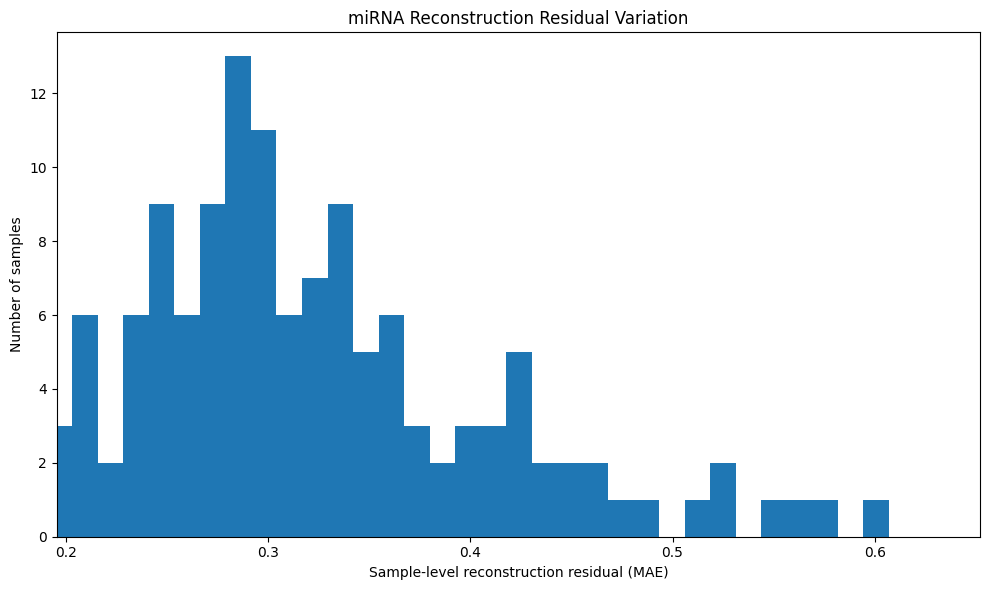

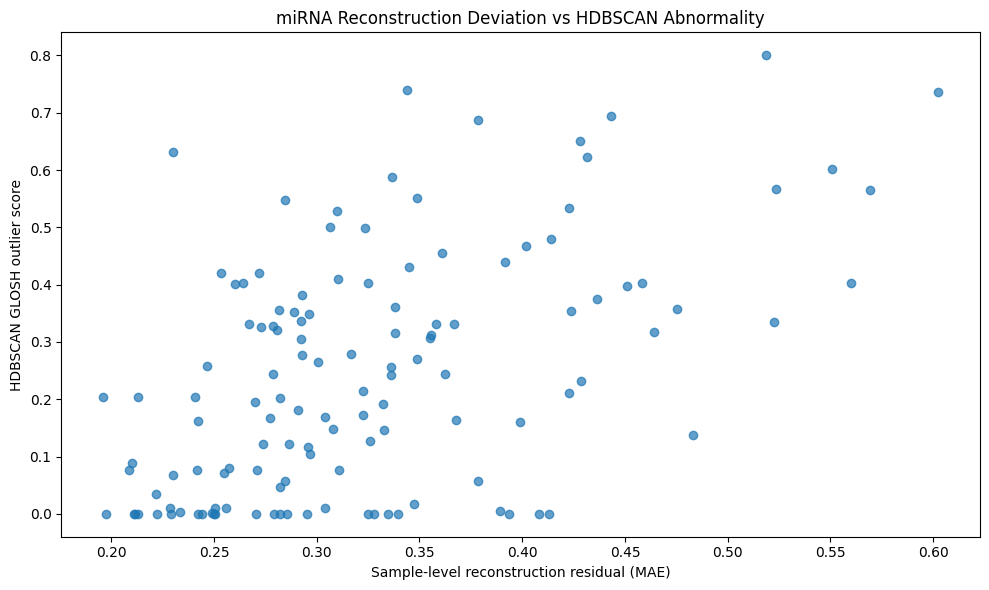

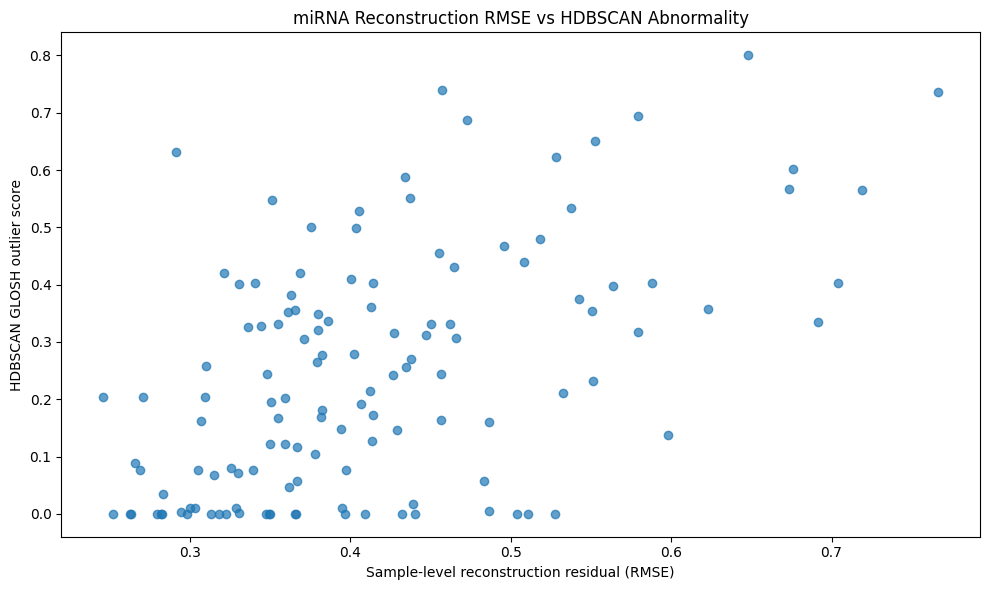


FILES SAVED

Sample-level residuals:
/content/miRNA_Reviewer_Corrected_Results/miRNA_Sample_Level_Reconstruction_Residuals.csv

Residual summary:
/content/miRNA_Reviewer_Corrected_Results/miRNA_Residual_Summary.csv

Absolute reconstruction error:
/content/miRNA_Reviewer_Corrected_Results/miRNA_Absolute_Reconstruction_Error_132x1000.npy

FINAL mRNA RESIDUAL ANALYSIS
Number of samples       : 132
Number of features      : 503
Mean residual MAE       : 0.328734
Median residual MAE     : 0.305261
Mean residual RMSE      : 0.417446
Median residual RMSE    : 0.390081
Spearman rho (MAE)      : 0.496901
Spearman p-value (MAE)  : 1.359423e-09
Spearman rho (RMSE)     : 0.506818
Spearman p-value (RMSE) : 5.618858e-10

Visualization range:
Central 98% MAE  = [0.195436, 0.652131]
Central 98% RMSE = [0.243608, 0.810538]

NOTE:
All 132 observations were retained in the numerical calculations and Spearman correlation tests.
The 1st–99th percentile restriction was used only for visualization.

Analysi

In [60]:
# ============================================================
# PART RES.1 — mRNA RESIDUAL VARIATION ANALYSIS
#
# Purpose:
#   Compare the current PCA-reconstructed/original mRNA test
#   representation with the DAE-reconstructed representation.
#
# Residual:
#
#       R_i = (1/D) * SUM_j |X_ij - Xhat_ij|
#
# Visualization:
#   Central 98% of residual values
#   = 1st percentile to 99th percentile
#
# IMPORTANT:
#   Extreme values are NOT removed from calculations.
#   They are only excluded from the visualization window.
#
# Spearman:
#   Reconstruction deviation vs HDBSCAN GLOSH outlier score
#
# CURRENT NOTEBOOK VARIABLES:
#
#   X_test_pca_reconstructed : (132, 1000)
#   reconstruction           : (132, 1000)
#   results["OutlierScore"]  : (132,)
# ============================================================


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr


# ============================================================
# 1. INPUT CHECK
# ============================================================

print("\n" + "=" * 80)
print("miRNA RESIDUAL VARIATION ANALYSIS")
print("=" * 80)


# ------------------------------------------------------------
# Use the variables that actually exist in the current
# notebook.
# ------------------------------------------------------------

X_original = np.asarray(
    X_test_pca_reconstructed
)

X_reconstructed = np.asarray(
    reconstruction
)

glosh_scores = np.asarray(
    results["OutlierScore"]
)


# ============================================================
# 2. SHAPE VALIDATION
# ============================================================

print("\nInput shapes")
print("-" * 80)

print(
    "Original representation :",
    X_original.shape
)

print(
    "DAE reconstruction      :",
    X_reconstructed.shape
)

print(
    "GLOSH scores            :",
    glosh_scores.shape
)


# ------------------------------------------------------------
# Validate dimensionality
# ------------------------------------------------------------

if X_original.ndim != 2:

    raise ValueError(
        "X_test_pca_reconstructed must be a 2-dimensional matrix."
    )


if X_reconstructed.ndim != 2:

    raise ValueError(
        "reconstruction must be a 2-dimensional matrix."
    )


if X_original.shape != X_reconstructed.shape:

    raise ValueError(
        "Original and reconstructed miRNA matrices "
        "must have identical shapes."
    )


if X_original.shape[0] != len(glosh_scores):

    raise ValueError(
        "Number of miRNA samples does not match "
        "number of HDBSCAN GLOSH scores."
    )


# ============================================================
# 3. SAMPLE-LEVEL RESIDUAL MAE
# ============================================================

absolute_error = np.abs(
    X_original -
    X_reconstructed
)


sample_residual_mae = np.mean(
    absolute_error,
    axis=1
)


# ============================================================
# 4. SAMPLE-LEVEL RMSE
# ============================================================

sample_residual_rmse = np.sqrt(
    np.mean(
        (
            X_original -
            X_reconstructed
        ) ** 2,
        axis=1
    )
)


# ============================================================
# 5. MAXIMUM FEATURE ERROR
# ============================================================

sample_max_error = np.max(
    absolute_error,
    axis=1
)


# ============================================================
# 6. CENTRAL 98% VISUALIZATION RANGE
#
# 1st percentile → 99th percentile
#
# IMPORTANT:
# These limits are ONLY for plotting.
# No samples are removed from numerical analysis.
# ============================================================

mae_lower = np.percentile(
    sample_residual_mae,
    1
)

mae_upper = np.percentile(
    sample_residual_mae,
    99
)

rmse_lower = np.percentile(
    sample_residual_rmse,
    1
)

rmse_upper = np.percentile(
    sample_residual_rmse,
    99
)


print("\nCentral 98% visualization range")
print("-" * 80)

print(
    f"MAE  : {mae_lower:.6f} "
    f"to {mae_upper:.6f}"
)

print(
    f"RMSE : {rmse_lower:.6f} "
    f"to {rmse_upper:.6f}"
)


# ============================================================
# 7. SUMMARY STATISTICS
#
# ALL 132 samples are retained.
# No extreme observations are removed.
# ============================================================

residual_summary = {

    "N":
        len(sample_residual_mae),

    "Features":
        X_original.shape[1],

    "Mean_MAE":
        np.mean(sample_residual_mae),

    "Median_MAE":
        np.median(sample_residual_mae),

    "SD_MAE":
        np.std(
            sample_residual_mae,
            ddof=1
        ),

    "Min_MAE":
        np.min(sample_residual_mae),

    "Max_MAE":
        np.max(sample_residual_mae),

    "Mean_RMSE":
        np.mean(sample_residual_rmse),

    "Median_RMSE":
        np.median(sample_residual_rmse),

    "SD_RMSE":
        np.std(
            sample_residual_rmse,
            ddof=1
        ),

    "Min_RMSE":
        np.min(sample_residual_rmse),

    "Max_RMSE":
        np.max(sample_residual_rmse),

    "Mean_Max_Feature_Error":
        np.mean(sample_max_error),

    "Max_Feature_Error":
        np.max(sample_max_error)
}


print("\nResidual Summary")
print("-" * 80)

for key, value in residual_summary.items():

    if isinstance(
        value,
        (
            int,
            np.integer
        )
    ):

        print(
            f"{key:<30}: {value}"
        )

    else:

        print(
            f"{key:<30}: {value:.6f}"
        )


# ============================================================
# 8. SAMPLE-LEVEL RESIDUAL TABLE
# ============================================================

residual_df = pd.DataFrame({

    "Sample_Index":
        np.arange(
            len(sample_residual_mae)
        ),

    "Residual_MAE":
        sample_residual_mae,

    "Residual_RMSE":
        sample_residual_rmse,

    "Max_Feature_Error":
        sample_max_error,

    "GLOSH_Outlier_Score":
        glosh_scores
})


# ============================================================
# 9. ADD EXISTING HDBSCAN INFORMATION
#
# This allows the residual table to be directly connected
# to the existing results dictionary.
# ============================================================

if "Cluster" in results:

    residual_df["Cluster"] = np.asarray(
        results["Cluster"]
    )


if "Probability" in results:

    residual_df["HDBSCAN_Probability"] = np.asarray(
        results["Probability"]
    )


if "Noise_Confidence" in results:

    residual_df["Noise_Confidence"] = np.asarray(
        results["Noise_Confidence"]
    )


if "Noise_Status" in results:

    residual_df["Noise_Status"] = np.asarray(
        results["Noise_Status"]
    )


if "Outlier_Category" in results:

    residual_df["Outlier_Category"] = np.asarray(
        results["Outlier_Category"]
    )


# ============================================================
# 10. SPEARMAN — MAE vs GLOSH
# ============================================================

rho_mae, p_mae = spearmanr(
    sample_residual_mae,
    glosh_scores
)


# ============================================================
# 11. SPEARMAN — RMSE vs GLOSH
# ============================================================

rho_rmse, p_rmse = spearmanr(
    sample_residual_rmse,
    glosh_scores
)


print("\nSpearman Rank Correlation")
print("-" * 80)

print(
    "Residual MAE vs GLOSH"
)

print(
    f"Spearman rho : {rho_mae:.6f}"
)

print(
    f"p-value      : {p_mae:.6e}"
)

print()

print(
    "Residual RMSE vs GLOSH"
)

print(
    f"Spearman rho : {rho_rmse:.6f}"
)

print(
    f"p-value      : {p_rmse:.6e}"
)


# ============================================================
# 12. ADD CORRELATION RESULTS TO SUMMARY
# ============================================================

residual_summary[
    "Spearman_Rho_MAE_GLOSH"
] = rho_mae

residual_summary[
    "Spearman_P_MAE_GLOSH"
] = p_mae

residual_summary[
    "Spearman_Rho_RMSE_GLOSH"
] = rho_rmse

residual_summary[
    "Spearman_P_RMSE_GLOSH"
] = p_rmse


# ============================================================
# 13. RESIDUAL HISTOGRAM
#
# Only the central 98% is displayed.
# ALL observations remain in the underlying data.
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    sample_residual_mae,
    bins=40
)

plt.xlim(
    mae_lower,
    mae_upper
)

plt.xlabel(
    "Sample-level reconstruction residual (MAE)"
)

plt.ylabel(
    "Number of samples"
)

plt.title(
    "miRNA Reconstruction Residual Variation"
)

plt.tight_layout()

plt.show()


# ============================================================
# 14. RESIDUAL vs GLOSH
#
# Visualization uses central 98% MAE range.
#
# IMPORTANT:
# Spearman correlation above uses ALL 132 samples.
# ============================================================

visual_mask = (
    sample_residual_mae >= mae_lower
) & (
    sample_residual_mae <= mae_upper
)


plt.figure(
    figsize=(10, 6)
)

plt.scatter(
    sample_residual_mae[
        visual_mask
    ],
    glosh_scores[
        visual_mask
    ],
    alpha=0.7
)

plt.xlabel(
    "Sample-level reconstruction residual (MAE)"
)

plt.ylabel(
    "HDBSCAN GLOSH outlier score"
)

plt.title(
    "miRNA Reconstruction Deviation vs HDBSCAN Abnormality"
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. RMSE vs GLOSH
# ============================================================

visual_mask_rmse = (
    sample_residual_rmse >= rmse_lower
) & (
    sample_residual_rmse <= rmse_upper
)


plt.figure(
    figsize=(10, 6)
)

plt.scatter(
    sample_residual_rmse[
        visual_mask_rmse
    ],
    glosh_scores[
        visual_mask_rmse
    ],
    alpha=0.7
)

plt.xlabel(
    "Sample-level reconstruction residual (RMSE)"
)

plt.ylabel(
    "HDBSCAN GLOSH outlier score"
)

plt.title(
    "miRNA Reconstruction RMSE vs HDBSCAN Abnormality"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. OUTPUT DIRECTORY
# ============================================================

if "OUTPUT_DIR" in globals():

    residual_output_dir = OUTPUT_DIR

elif "RESULTS_DIR" in globals():

    residual_output_dir = RESULTS_DIR

else:

    residual_output_dir = "miRNA_Residual_Analysis"


os.makedirs(
    residual_output_dir,
    exist_ok=True
)


# ============================================================
# 17. SAVE SAMPLE-LEVEL RESIDUALS
# ============================================================

residual_file = os.path.join(
    residual_output_dir,
    "miRNA_Sample_Level_Reconstruction_Residuals.csv"
)


residual_df.to_csv(
    residual_file,
    index=False
)


# ============================================================
# 18. SAVE SUMMARY
# ============================================================

summary_df = pd.DataFrame([
    residual_summary
])


summary_file = os.path.join(
    residual_output_dir,
    "miRNA_Residual_Summary.csv"
)


summary_df.to_csv(
    summary_file,
    index=False
)


# ============================================================
# 19. SAVE RESIDUAL MATRICES
#
# Useful for later gene-level analysis.
# ============================================================

absolute_error_file = os.path.join(
    residual_output_dir,
    "miRNA_Absolute_Reconstruction_Error_132x1000.npy"
)


np.save(
    absolute_error_file,
    absolute_error
)


# ============================================================
# 20. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print(
    "\nSample-level residuals:"
)

print(
    residual_file
)

print(
    "\nResidual summary:"
)

print(
    summary_file
)

print(
    "\nAbsolute reconstruction error:"
)

print(
    absolute_error_file
)


# ============================================================
# 21. FINAL INTERPRETATION
# ============================================================

print("\n" + "=" * 80)
print("FINAL mRNA RESIDUAL ANALYSIS")
print("=" * 80)

print(
    f"Number of samples       : "
    f"{len(sample_residual_mae)}"
)

print(
    f"Number of features      : "
    f"{X_original.shape[1]}"
)

print(
    f"Mean residual MAE       : "
    f"{np.mean(sample_residual_mae):.6f}"
)

print(
    f"Median residual MAE     : "
    f"{np.median(sample_residual_mae):.6f}"
)

print(
    f"Mean residual RMSE      : "
    f"{np.mean(sample_residual_rmse):.6f}"
)

print(
    f"Median residual RMSE    : "
    f"{np.median(sample_residual_rmse):.6f}"
)

print(
    f"Spearman rho (MAE)      : "
    f"{rho_mae:.6f}"
)

print(
    f"Spearman p-value (MAE)  : "
    f"{p_mae:.6e}"
)

print(
    f"Spearman rho (RMSE)     : "
    f"{rho_rmse:.6f}"
)

print(
    f"Spearman p-value (RMSE) : "
    f"{p_rmse:.6e}"
)

print(
    "\nVisualization range:"
)

print(
    f"Central 98% MAE  = "
    f"[{mae_lower:.6f}, {mae_upper:.6f}]"
)

print(
    f"Central 98% RMSE = "
    f"[{rmse_lower:.6f}, {rmse_upper:.6f}]"
)

print(
    "\nNOTE:"
)

print(
    "All 132 observations were retained in the numerical "
    "calculations and Spearman correlation tests."
)

print(
    "The 1st–99th percentile restriction was used only "
    "for visualization."
)

print(
    "\nAnalysis completed successfully."
)



M4 IEEE DETAILED RESULTS
 Noise_Level  Actual_Noise_STD  Mean_MAE  Median_MAE   SD_MAE  Mean_RMSE  Median_RMSE  SD_RMSE  Max_MAE  Max_RMSE
        0.10          0.100268  0.562846    0.542557 0.154586   0.748535     0.718360 0.209368 1.101337  1.442622
        0.25          0.250669  0.595035    0.571071 0.148464   0.784394     0.748647 0.201725 1.122346  1.467207
        0.50          0.501338  0.695723    0.666368 0.132658   0.900013     0.852169 0.180916 1.183626  1.543202
        1.00          1.002676  0.989361    0.968463 0.105865   1.254244     1.221999 0.141659 1.392631  1.801441


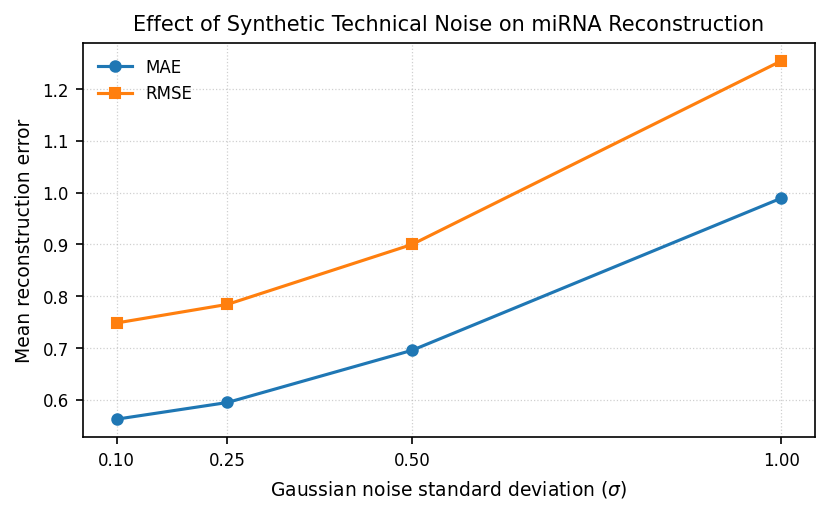

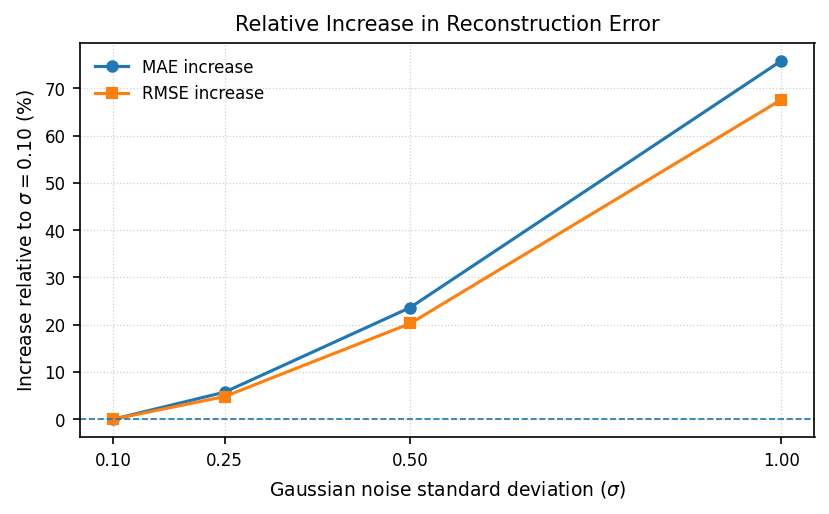

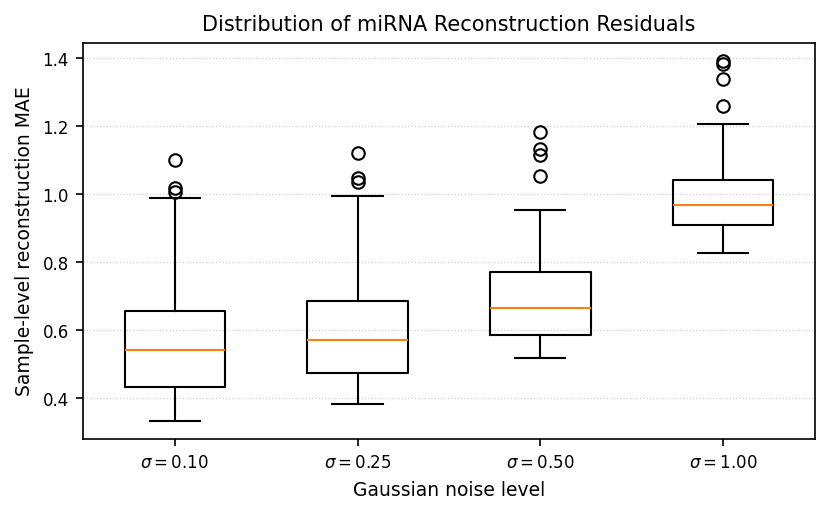

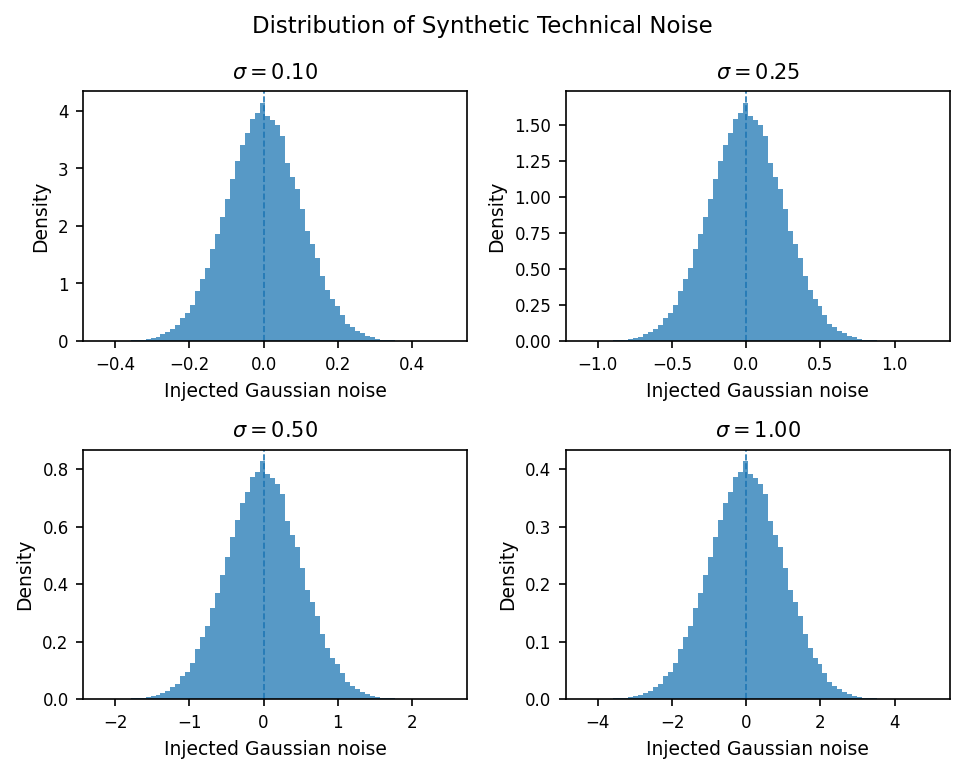

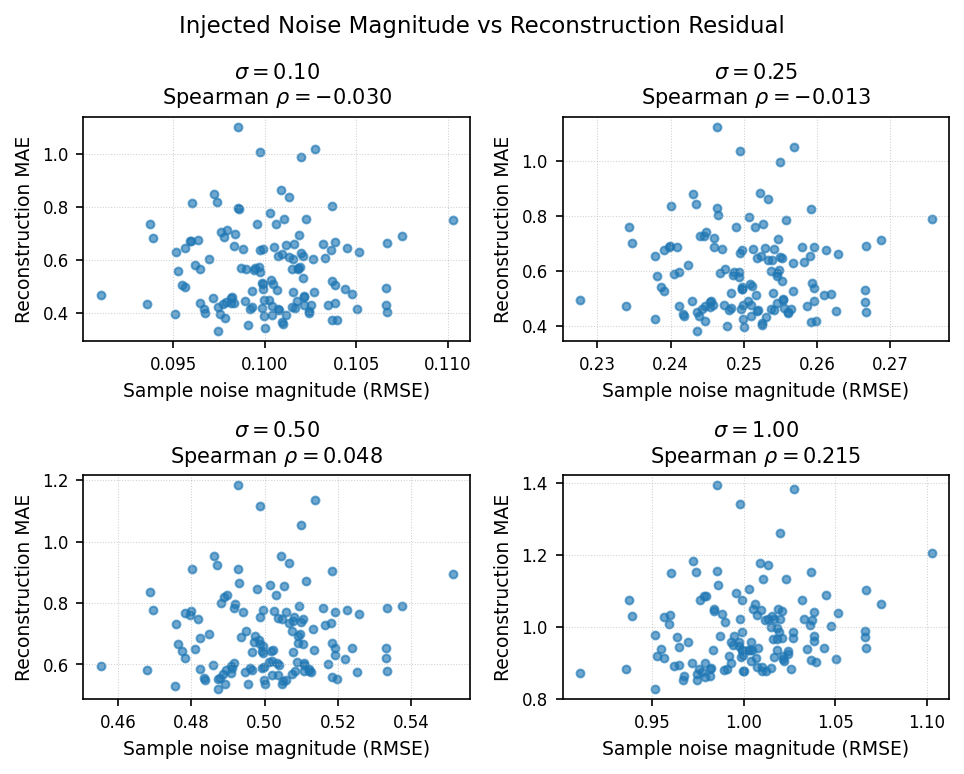

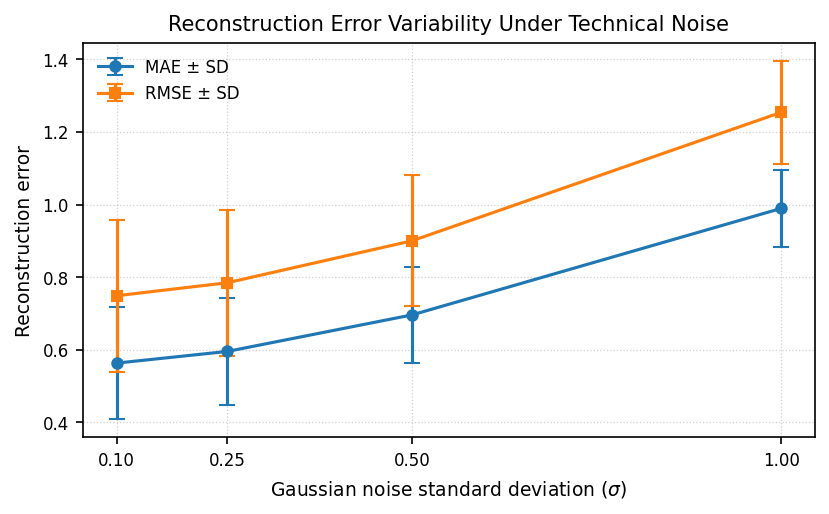

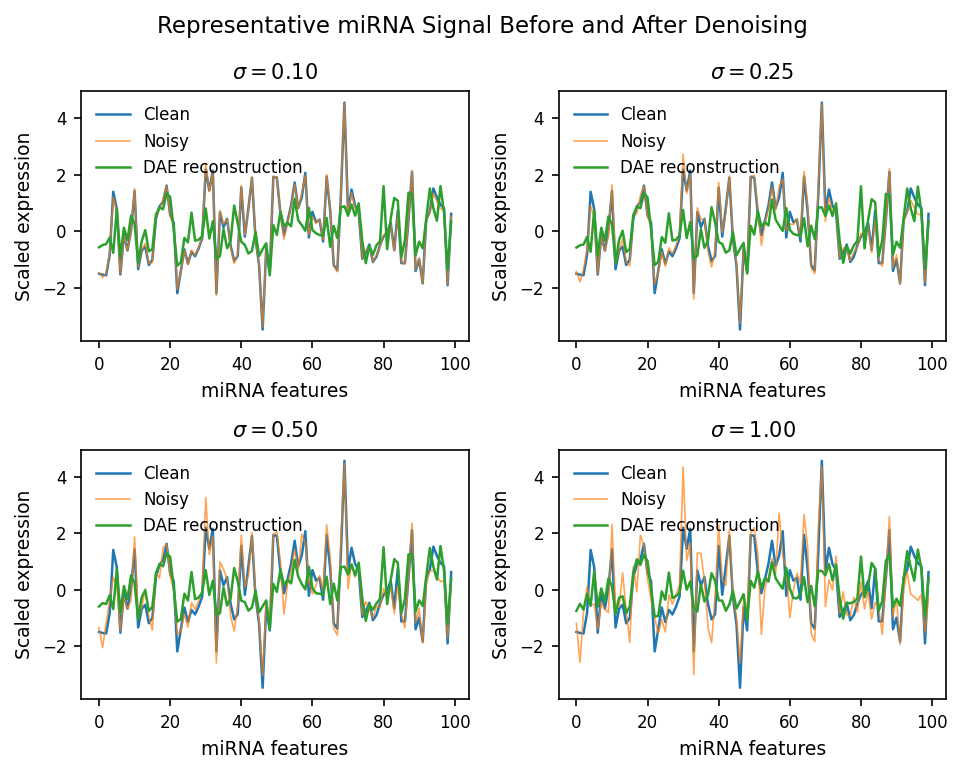

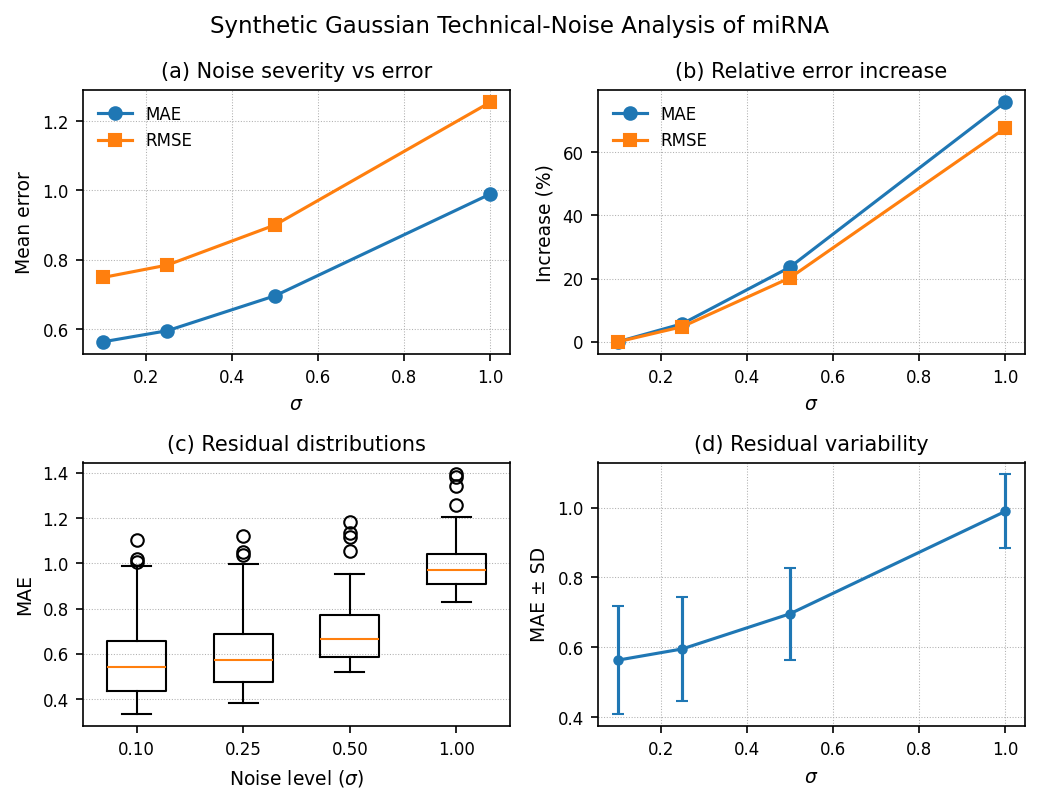



M4 — FINAL SYNTHETIC TECHNICAL-NOISE ANALYSIS

Noise σ = 0.10
  Actual noise STD : 0.100268
  Mean MAE         : 0.562846
  Median MAE       : 0.542557
  Mean RMSE        : 0.748535
  Median RMSE      : 0.718360

Noise σ = 0.25
  Actual noise STD : 0.250669
  Mean MAE         : 0.595035
  Median MAE       : 0.571071
  Mean RMSE        : 0.784394
  Median RMSE      : 0.748647

Noise σ = 0.50
  Actual noise STD : 0.501338
  Mean MAE         : 0.695723
  Median MAE       : 0.666368
  Mean RMSE        : 0.900013
  Median RMSE      : 0.852169

Noise σ = 1.00
  Actual noise STD : 1.002676
  Mean MAE         : 0.989361
  Median MAE       : 0.968463
  Mean RMSE        : 1.254244
  Median RMSE      : 1.221999


IEEE VISUALIZATIONS SAVED
/content/miRNA_Reviewer_Corrected_Results/M4_IEEE_Visualizations

Generated figures:
   Fig_M4_01_Noise_vs_Error.pdf
   Fig_M4_02_Relative_Error_Increase.pdf
   Fig_M4_03_Residual_Boxplot.pdf
   Fig_M4_04_Gaussian_Noise_Distributions.pdf
   Fig_M4_05_Noise_vs_

In [61]:
# ============================================================
# M4 — IEEE-QUALITY SYNTHETIC TECHNICAL NOISE VISUALIZATION
# mRNA
#
# IMPORTANT:
# This visualization uses the EXACT Gaussian noise procedure
# from the original M4 experiment.
#
# Clean scaled data:
#       X_test_scaled
#
# Noise:
#       N(0, sigma^2)
#
# Noisy data:
#       X_noisy = X_test_scaled + noise
#
# DAE:
#       dae_mse.predict(X_noisy)
#
# Residual:
#       mean(|X_noisy - reconstruction|)
# ============================================================


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr


# ============================================================
# 1. SETTINGS
# ============================================================

IEEE_OUTPUT_DIR = os.path.join(
    OUTPUT_DIR,
    "M4_IEEE_Visualizations"
)

os.makedirs(
    IEEE_OUTPUT_DIR,
    exist_ok=True
)

NOISE_LEVELS = [
    0.10,
    0.25,
    0.50,
    1.00
]

SEED = 42


# ============================================================
# 2. RE-RUN EXACT M4 EXPERIMENT
# ============================================================

m4_detailed_results = []

m4_noise = {}
m4_noisy_data = {}
m4_reconstruction = {}
m4_mae = {}
m4_rmse = {}


for level in NOISE_LEVELS:

    # --------------------------------------------------------
    # EXACT ORIGINAL NOISE INJECTION
    # --------------------------------------------------------

    rng = np.random.default_rng(SEED)

    noise = rng.normal(
        loc=0.0,
        scale=level,
        size=X_test_scaled.shape
    )

    X_noisy = X_test_scaled + noise


    # --------------------------------------------------------
    # DAE RECONSTRUCTION
    # --------------------------------------------------------

    reconstruction = dae_mse.predict(
        X_noisy,
        verbose=0
    )


    # --------------------------------------------------------
    # SAMPLE-LEVEL MAE
    # --------------------------------------------------------

    mae = np.mean(
        np.abs(
            X_noisy -
            reconstruction
        ),
        axis=1
    )


    # --------------------------------------------------------
    # SAMPLE-LEVEL RMSE
    # --------------------------------------------------------

    rmse = np.sqrt(
        np.mean(
            (
                X_noisy -
                reconstruction
            ) ** 2,
            axis=1
        )
    )


    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    m4_noise[level] = noise

    m4_noisy_data[level] = X_noisy

    m4_reconstruction[level] = reconstruction

    m4_mae[level] = mae

    m4_rmse[level] = rmse


    # --------------------------------------------------------
    # SUMMARY
    # --------------------------------------------------------

    m4_detailed_results.append({

        "Noise_Level": level,

        "Actual_Noise_STD":
            np.std(noise),

        "Mean_MAE":
            np.mean(mae),

        "Median_MAE":
            np.median(mae),

        "SD_MAE":
            np.std(mae, ddof=1),

        "Mean_RMSE":
            np.mean(rmse),

        "Median_RMSE":
            np.median(rmse),

        "SD_RMSE":
            np.std(rmse, ddof=1),

        "Max_MAE":
            np.max(mae),

        "Max_RMSE":
            np.max(rmse)

    })


m4_df = pd.DataFrame(
    m4_detailed_results
)


# ============================================================
# 3. SAVE DETAILED RESULTS
# ============================================================

m4_df.to_csv(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "M4_IEEE_Detailed_Results.csv"
    ),
    index=False
)


print("\n")
print("=" * 80)
print("M4 IEEE DETAILED RESULTS")
print("=" * 80)

print(
    m4_df.to_string(
        index=False
    )
)


# ============================================================
# 4. IEEE STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",

    "font.serif":
        ["Times New Roman", "Times"],

    "font.size":
        9,

    "axes.labelsize":
        9,

    "axes.titlesize":
        10,

    "xtick.labelsize":
        8,

    "ytick.labelsize":
        8,

    "legend.fontsize":
        8,

    "axes.linewidth":
        0.8,

    "xtick.major.width":
        0.8,

    "ytick.major.width":
        0.8,

    "figure.dpi":
        150,

    "savefig.dpi":
        600,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42
})


# ============================================================
# FIGURE 1
# NOISE LEVEL vs MAE / RMSE
# ============================================================

fig, ax = plt.subplots(
    figsize=(5.6, 3.5)
)

ax.plot(
    m4_df["Noise_Level"],
    m4_df["Mean_MAE"],
    marker="o",
    markersize=5,
    linewidth=1.5,
    label="MAE"
)

ax.plot(
    m4_df["Noise_Level"],
    m4_df["Mean_RMSE"],
    marker="s",
    markersize=5,
    linewidth=1.5,
    label="RMSE"
)

ax.set_xlabel(
    "Gaussian noise standard deviation ($\\sigma$)"
)

ax.set_ylabel(
    "Mean reconstruction error"
)

ax.set_title(
    "Effect of Synthetic Technical Noise on miRNA Reconstruction"
)

ax.set_xticks(
    NOISE_LEVELS
)

ax.legend(
    frameon=False
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.6,
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_01_Noise_vs_Error.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_01_Noise_vs_Error.png"
    ),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 2
# ERROR INCREASE RELATIVE TO LOWEST NOISE
# ============================================================

baseline_mae = m4_df["Mean_MAE"].iloc[0]

baseline_rmse = m4_df["Mean_RMSE"].iloc[0]

mae_increase = (
    (
        m4_df["Mean_MAE"]
        -
        baseline_mae
    )
    /
    baseline_mae
) * 100

rmse_increase = (
    (
        m4_df["Mean_RMSE"]
        -
        baseline_rmse
    )
    /
    baseline_rmse
) * 100


fig, ax = plt.subplots(
    figsize=(5.6, 3.5)
)

ax.plot(
    m4_df["Noise_Level"],
    mae_increase,
    marker="o",
    linewidth=1.5,
    markersize=5,
    label="MAE increase"
)

ax.plot(
    m4_df["Noise_Level"],
    rmse_increase,
    marker="s",
    linewidth=1.5,
    markersize=5,
    label="RMSE increase"
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

ax.set_xlabel(
    "Gaussian noise standard deviation ($\\sigma$)"
)

ax.set_ylabel(
    "Increase relative to $\\sigma=0.10$ (%)"
)

ax.set_title(
    "Relative Increase in Reconstruction Error"
)

ax.set_xticks(
    NOISE_LEVELS
)

ax.legend(
    frameon=False
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.6,
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_02_Relative_Error_Increase.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_02_Relative_Error_Increase.png"
    ),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 3
# SAMPLE-LEVEL RESIDUAL DISTRIBUTIONS
# ============================================================

fig, ax = plt.subplots(
    figsize=(5.6, 3.5)
)

positions = np.arange(
    1,
    len(NOISE_LEVELS) + 1
)

box_data = [
    m4_mae[level]
    for level in NOISE_LEVELS
]

bp = ax.boxplot(
    box_data,
    positions=positions,
    widths=0.55,
    showfliers=True
)

ax.set_xticks(
    positions
)

ax.set_xticklabels(
    [
        f"$\\sigma={x:.2f}$"
        for x in NOISE_LEVELS
    ]
)

ax.set_xlabel(
    "Gaussian noise level"
)

ax.set_ylabel(
    "Sample-level reconstruction MAE"
)

ax.set_title(
    "Distribution of miRNA Reconstruction Residuals"
)

ax.grid(
    axis="y",
    linestyle=":",
    linewidth=0.6,
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_03_Residual_Boxplot.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_03_Residual_Boxplot.png"
    ),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 4
# GAUSSIAN NOISE DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(6.5, 5.2)
)

axes = axes.flatten()


for ax, level in zip(
    axes,
    NOISE_LEVELS
):

    noise = m4_noise[level].flatten()

    # Limit plotting points only
    # numerical calculations remain complete

    if len(noise) > 100000:

        rng = np.random.default_rng(
            SEED
        )

        idx = rng.choice(
            len(noise),
            100000,
            replace=False
        )

        noise_plot = noise[idx]

    else:

        noise_plot = noise


    ax.hist(
        noise_plot,
        bins=70,
        density=True,
        alpha=0.75
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=0.8
    )

    ax.set_title(
        f"$\\sigma={level:.2f}$"
    )

    ax.set_xlabel(
        "Injected Gaussian noise"
    )

    ax.set_ylabel(
        "Density"
    )


fig.suptitle(
    "Distribution of Synthetic Technical Noise",
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_04_Gaussian_Noise_Distributions.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_04_Gaussian_Noise_Distributions.png"
    ),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 5
# NOISE MAGNITUDE vs RECONSTRUCTION ERROR
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(6.5, 5.2)
)

axes = axes.flatten()


for ax, level in zip(
    axes,
    NOISE_LEVELS
):

    noise = m4_noise[level]

    mae = m4_mae[level]


    sample_noise_rmse = np.sqrt(
        np.mean(
            noise ** 2,
            axis=1
        )
    )


    rho, p = spearmanr(
        sample_noise_rmse,
        mae
    )


    ax.scatter(
        sample_noise_rmse,
        mae,
        s=14,
        alpha=0.65
    )


    ax.set_title(
        f"$\\sigma={level:.2f}$"
        f"\nSpearman $\\rho={rho:.3f}$"
    )

    ax.set_xlabel(
        "Sample noise magnitude (RMSE)"
    )

    ax.set_ylabel(
        "Reconstruction MAE"
    )

    ax.grid(
        True,
        linestyle=":",
        linewidth=0.5,
        alpha=0.6
    )


fig.suptitle(
    "Injected Noise Magnitude vs Reconstruction Residual",
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_05_Noise_vs_Residual.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_05_Noise_vs_Residual.png"
    ),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 6
# MEAN ± SD
# ============================================================

fig, ax = plt.subplots(
    figsize=(5.6, 3.5)
)

ax.errorbar(
    m4_df["Noise_Level"],
    m4_df["Mean_MAE"],
    yerr=m4_df["SD_MAE"],
    marker="o",
    markersize=5,
    linewidth=1.5,
    capsize=4,
    label="MAE ± SD"
)

ax.errorbar(
    m4_df["Noise_Level"],
    m4_df["Mean_RMSE"],
    yerr=m4_df["SD_RMSE"],
    marker="s",
    markersize=5,
    linewidth=1.5,
    capsize=4,
    label="RMSE ± SD"
)

ax.set_xlabel(
    "Gaussian noise standard deviation ($\\sigma$)"
)

ax.set_ylabel(
    "Reconstruction error"
)

ax.set_title(
    "Reconstruction Error Variability Under Technical Noise"
)

ax.set_xticks(
    NOISE_LEVELS
)

ax.legend(
    frameon=False
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.6,
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_06_Error_Variability.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_06_Error_Variability.png"
    ),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 7
# CLEAN vs NOISY vs DAE RECONSTRUCTION
# REPRESENTATIVE SAMPLE
# ============================================================

sample_index = 0

fig, axes = plt.subplots(
    2,
    2,
    figsize=(6.5, 5.2)
)

axes = axes.flatten()


for ax, level in zip(
    axes,
    NOISE_LEVELS
):

    clean = X_test_scaled[
        sample_index
    ]

    noisy = m4_noisy_data[
        level
    ][sample_index]

    reconstructed = m4_reconstruction[
        level
    ][sample_index]


    n_features = len(clean)

    # Show first 100 features
    plot_features = min(
        100,
        n_features
    )

    x_axis = np.arange(
        plot_features
    )


    ax.plot(
        x_axis,
        clean[:plot_features],
        linewidth=1.2,
        label="Clean"
    )

    ax.plot(
        x_axis,
        noisy[:plot_features],
        linewidth=0.8,
        alpha=0.7,
        label="Noisy"
    )

    ax.plot(
        x_axis,
        reconstructed[:plot_features],
        linewidth=1.2,
        label="DAE reconstruction"
    )


    ax.set_title(
        f"$\\sigma={level:.2f}$"
    )

    ax.set_xlabel(
        "miRNA features"
    )

    ax.set_ylabel(
        "Scaled expression"
    )

    ax.legend(
        frameon=False
    )


fig.suptitle(
    "Representative miRNA Signal Before and After Denoising",
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_07_Clean_Noisy_Reconstruction.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_07_Clean_Noisy_Reconstruction.png"
    ),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 8
# IEEE FINAL SUMMARY
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(7.0, 5.4)
)


# ------------------------------------------------------------
# (a) Noise vs error
# ------------------------------------------------------------

ax = axes[0, 0]

ax.plot(
    m4_df["Noise_Level"],
    m4_df["Mean_MAE"],
    marker="o",
    linewidth=1.5,
    label="MAE"
)

ax.plot(
    m4_df["Noise_Level"],
    m4_df["Mean_RMSE"],
    marker="s",
    linewidth=1.5,
    label="RMSE"
)

ax.set_xlabel(
    "$\\sigma$"
)

ax.set_ylabel(
    "Mean error"
)

ax.set_title(
    "(a) Noise severity vs error"
)

ax.legend(
    frameon=False
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.5
)


# ------------------------------------------------------------
# (b) Error increase
# ------------------------------------------------------------

ax = axes[0, 1]

ax.plot(
    m4_df["Noise_Level"],
    mae_increase,
    marker="o",
    linewidth=1.5,
    label="MAE"
)

ax.plot(
    m4_df["Noise_Level"],
    rmse_increase,
    marker="s",
    linewidth=1.5,
    label="RMSE"
)

ax.set_xlabel(
    "$\\sigma$"
)

ax.set_ylabel(
    "Increase (%)"
)

ax.set_title(
    "(b) Relative error increase"
)

ax.legend(
    frameon=False
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.5
)


# ------------------------------------------------------------
# (c) Residual boxplot
# ------------------------------------------------------------

ax = axes[1, 0]

ax.boxplot(
    [
        m4_mae[level]
        for level in NOISE_LEVELS
    ],
    labels=[
        f"{level:.2f}"
        for level in NOISE_LEVELS
    ],
    widths=0.55
)

ax.set_xlabel(
    "Noise level ($\\sigma$)"
)

ax.set_ylabel(
    "MAE"
)

ax.set_title(
    "(c) Residual distributions"
)

ax.grid(
    axis="y",
    linestyle=":",
    linewidth=0.5
)


# ------------------------------------------------------------
# (d) Mean ± SD
# ------------------------------------------------------------

ax = axes[1, 1]

ax.errorbar(
    m4_df["Noise_Level"],
    m4_df["Mean_MAE"],
    yerr=m4_df["SD_MAE"],
    marker="o",
    linewidth=1.5,
    markersize=4,
    capsize=3
)

ax.set_xlabel(
    "$\\sigma$"
)

ax.set_ylabel(
    "MAE ± SD"
)

ax.set_title(
    "(d) Residual variability"
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.5
)


fig.suptitle(
    "Synthetic Gaussian Technical-Noise Analysis of miRNA",
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_08_IEEE_Final_Summary.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_08_IEEE_Final_Summary.png"
    ),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. FINAL NUMERICAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("M4 — FINAL SYNTHETIC TECHNICAL-NOISE ANALYSIS")
print("=" * 80)

for _, row in m4_df.iterrows():

    print(
        f"\nNoise σ = {row['Noise_Level']:.2f}"
    )

    print(
        f"  Actual noise STD : "
        f"{row['Actual_Noise_STD']:.6f}"
    )

    print(
        f"  Mean MAE         : "
        f"{row['Mean_MAE']:.6f}"
    )

    print(
        f"  Median MAE       : "
        f"{row['Median_MAE']:.6f}"
    )

    print(
        f"  Mean RMSE        : "
        f"{row['Mean_RMSE']:.6f}"
    )

    print(
        f"  Median RMSE      : "
        f"{row['Median_RMSE']:.6f}"
    )


# ============================================================
# 6. FINAL OUTPUT LOCATION
# ============================================================

print("\n")
print("=" * 80)
print("IEEE VISUALIZATIONS SAVED")
print("=" * 80)

print(
    IEEE_OUTPUT_DIR
)

print("\nGenerated figures:")

for filename in sorted(
    os.listdir(
        IEEE_OUTPUT_DIR
    )
):

    if filename.endswith(".pdf"):

        print(
            "  ",
            filename
        )

print("\nAnalysis completed successfully.")